In [ ]:
%%writefile data1.csv
c1,c2
A,1
B,2
C,3

Writing data1.csv


In [ ]:
%%writefile data2.csv
c1,c2
A,10
B,20
C,30

Writing data2.csv


In [ ]:
import pandas as pd

In [ ]:
left = pd.read_csv('/content/data1.csv')
right = pd.read_csv('/content/data2.csv')
display(left, right)

,c1,c2
0,A,1
1,B,2
2,C,3


,c1,c2
0,A,10
1,B,20
2,C,30


In [ ]:
out = pd.merge(left, right, on = 'c1', how = 'outer', indicator =True)
out

,c1,c2_x,c2_y,_merge
0,A,1,10,both
1,B,2,20,both
2,C,3,30,both


In [ ]:
# LEFT JOIN
out[out['_merge'].isin(['left_only', 'both'])]

,c1,c2_x,c2_y,_merge
0,A,1,10,both
1,B,2,20,both
2,C,3,30,both


In [ ]:
# RIGHT JOIN
out[out['_merge'].isin(['right_only', 'both'])]

,c1,c2_x,c2_y,_merge
0,A,1,10,both
1,B,2,20,both
2,C,3,30,both


In [ ]:
# INNER JOIN
out[out['_merge'].isin(['both'])]

,c1,c2_x,c2_y,_merge
0,A,1,10,both
1,B,2,20,both
2,C,3,30,both


In [ ]:
w1s.head()

NameError: name 'w1s' is not defined

In [ ]:
out = pd.merge(w1s, w2s, on = 'c1', how = 'outer', indicator =True)
out

Identify which customers visited

In [ ]:
out[out['merge'] == 'left_only']

In [ ]:
out[out['merge'] == 'right_only']

`.apply(Callable)` and `.merge(Callable/dictionary)`

In [ ]:
import numpy as np

In [ ]:
arr = np.arange(1, 31).reshape(5, 6)
arr

array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29, 30]])

In [ ]:
df = pd.DataFrame(arr, index = ['r1', 'r2', 'r3', 'r4', 'r5'],
                  columns = ['c1', 'c2', 'c3', 'c4', 'c5', 'c6'])
df

,c1,c2,c3,c4,c5,c6
r1,1,2,3,4,5,6
r2,7,8,9,10,11,12
r3,13,14,15,16,17,18
r4,19,20,21,22,23,24
r5,25,26,27,28,29,30


In [ ]:
df.merge()

TypeError: DataFrame.merge() missing 1 required positional argument: 'right'

`.map(Callable)` - Callable is applied on whole dataframe
- without considering `rows` or `column`
  - ufunc - np.sin
  - user defined function - square
  - a lambda function
- it is applicable for Callable with only `one parameter`. if any callable have multiple parameters `map` is not applicable use, `apply()`

In [ ]:
df.map(np.sin)

,c1,c2,c3,c4,c5,c6
r1,0.841471,0.909297,0.141120,-0.756802,-0.958924,-0.279415
r2,0.656987,0.989358,0.412118,-0.544021,-0.999990,-0.536573
r3,0.420167,0.990607,0.650288,-0.287903,-0.961397,-0.750987
r4,0.149877,0.912945,0.836656,-0.008851,-0.846220,-0.905578
r5,-0.132352,0.762558,0.956376,0.270906,-0.663634,-0.988032


In [ ]:
def square(x):
  return x**2

In [ ]:
# user defined function
df.map(square)

,c1,c2,c3,c4,c5,c6
r1,1,4,9,16,25,36
r2,49,64,81,100,121,144
r3,169,196,225,256,289,324
r4,361,400,441,484,529,576
r5,625,676,729,784,841,900


In [ ]:
# Lambda function
df.map(lambda x: x%2 == 0)

,c1,c2,c3,c4,c5,c6
r1,False,True,False,True,False,True
r2,False,True,False,True,False,True
r3,False,True,False,True,False,True
r4,False,True,False,True,False,True
r5,False,True,False,True,False,True


In [ ]:
# ufunc
df.map(np.sin)

,c1,c2,c3,c4,c5,c6
r1,0.841471,0.909297,0.141120,-0.756802,-0.958924,-0.279415
r2,0.656987,0.989358,0.412118,-0.544021,-0.999990,-0.536573
r3,0.420167,0.990607,0.650288,-0.287903,-0.961397,-0.750987
r4,0.149877,0.912945,0.836656,-0.008851,-0.846220,-0.905578
r5,-0.132352,0.762558,0.956376,0.270906,-0.663634,-0.988032


`.apply(Callable)` - Can be applied on Columns/rows of a dataframe
- As a callable
  - a ufunc
  - an user defined function
  - a lambda function
- Use callables with `multiple parameters`

In [ ]:
df.apply(np.sin) # df.apply(np.in, axis = 0)

,c1,c2,c3,c4,c5,c6
r1,0.841471,0.909297,0.141120,-0.756802,-0.958924,-0.279415
r2,0.656987,0.989358,0.412118,-0.544021,-0.999990,-0.536573
r3,0.420167,0.990607,0.650288,-0.287903,-0.961397,-0.750987
r4,0.149877,0.912945,0.836656,-0.008851,-0.846220,-0.905578
r5,-0.132352,0.762558,0.956376,0.270906,-0.663634,-0.988032


In [ ]:
# df.apply
np.sin(df['c1']), np.sin(df['c2']), np.sin(df['c3']), np.sin(df['c4']), np.sin(df['c5']), np.sin(df['c6'])

(r1    0.841471
 r2    0.656987
 r3    0.420167
 r4    0.149877
 r5   -0.132352
 Name: c1, dtype: float64,
 r1    0.909297
 r2    0.989358
 r3    0.990607
 r4    0.912945
 r5    0.762558
 Name: c2, dtype: float64,
 r1    0.141120
 r2    0.412118
 r3    0.650288
 r4    0.836656
 r5    0.956376
 Name: c3, dtype: float64,
 r1   -0.756802
 r2   -0.544021
 r3   -0.287903
 r4   -0.008851
 r5    0.270906
 Name: c4, dtype: float64,
 r1   -0.958924
 r2   -0.999990
 r3   -0.961397
 r4   -0.846220
 r5   -0.663634
 Name: c5, dtype: float64,
 r1   -0.279415
 r2   -0.536573
 r3   -0.750987
 r4   -0.905578
 r5   -0.988032
 Name: c6, dtype: float64)

In [ ]:
 # df.apply(square, axis = 0)

,c1,c2,c3,c4,c5,c6
r1,1,4,9,16,25,36
r2,49,64,81,100,121,144
r3,169,196,225,256,289,324
r4,361,400,441,484,529,576
r5,625,676,729,784,841,900


In [ ]:
square(df['c1'])

,c1
r1,1
r2,49
r3,169
r4,361
r5,625


In [ ]:
df.apply(lambda x: x%2 == 0)

,c1,c2,c3,c4,c5,c6
r1,False,True,False,True,False,True
r2,False,True,False,True,False,True
r3,False,True,False,True,False,True
r4,False,True,False,True,False,True
r5,False,True,False,True,False,True


The following function is applicable only on containers, not on individual elements

In [ ]:
def user_index(x): # x as a iterbale/container like (list/tuple/array.series)
  return x[0]

In [ ]:
df.map(user_index)

TypeError: 'int' object is not subscriptable

In [ ]:
user_index(1)

TypeError: 'int' object is not subscriptable

In [ ]:
df.apply(user_index)

/tmp/ipykernel_612/3191798060.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return x[0]


,0
c1,1
c2,2
c3,3
c4,4
c5,5
c6,6


In [ ]:
user_index(df['c1']), user_index(df['c2'])

/tmp/ipykernel_612/3191798060.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return x[0]


(np.int64(1), np.int64(2))

In [ ]:
df.apply(user_index, axis = 1)

/tmp/ipykernel_612/3191798060.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return x[0]


,0
r1,1
r2,7
r3,13
r4,19
r5,25


In [ ]:
df

,c1,c2,c3,c4,c5,c6
r1,1,2,3,4,5,6
r2,7,8,9,10,11,12
r3,13,14,15,16,17,18
r4,19,20,21,22,23,24
r5,25,26,27,28,29,30


In [ ]:
def lin_trans(x, a, b):
  return a*x+b

In [ ]:
df.apply(lin_trans)

TypeError: lin_trans() missing 2 required positional arguments: 'a' and 'b'

In [ ]:
a, b = 2,5

In [ ]:
# through args = (tuple), we can additional positional arguments - ORDER MATTERS
df.apply(lin_trans, args = (a, b))

,c1,c2,c3,c4,c5,c6
r1,7,9,11,13,15,17
r2,19,21,23,25,27,29
r3,31,33,35,37,39,41
r4,43,45,47,49,51,53
r5,55,57,59,61,63,65


In [ ]:
def lin_trans(x, *, a, b):
  return a*x+b

In [ ]:
df[['c1', 'c2', 'c3']].apply(lin_trans, args = (a, b))

TypeError: lin_trans() takes 1 positional argument but 3 were given

In [ ]:
%%writefile data3.csv
c1,c2,c3
a,1,Male
b,0,Female
c,1,Male
d,0,Female
e,1,Male
f,0,Female

Writing data3.csv


In [ ]:
df2 = pd.read_csv('/content/data3.csv')
df2

,c1,c2,c3
0,a,1,Male
1,b,0,Female
2,c,1,Male
3,d,0,Female
4,e,1,Male
5,f,0,Female


In c2
- map {1: 'yes', 0: 'no'}

In c3
- Map {'Male': 1, 'Female':0}

In [ ]:
df2['c2'].map({1: 'yes', 0: 'no'})

,c2
0,yes
1,no
2,yes
3,no
4,yes
5,no


In [ ]:
df2['c3'].map({'Male': 1, 'Female':0})

,c3
0,1
1,0
2,1
3,0
4,1
5,0


In [ ]:
df2

,c1,c2,c3
0,a,1,Male
1,b,0,Female
2,c,1,Male
3,d,0,Female
4,e,1,Male
5,f,0,Female


In [ ]:
df2['c3'] = df2['c3'].map({'Male': 1, 'Female':0})
df2

,c1,c2,c3
0,a,1,1
1,b,0,0
2,c,1,1
3,d,0,0
4,e,1,1
5,f,0,0


In [ ]:
df2

,c1,c2,c3
0,a,1,1
1,b,0,0
2,c,1,1
3,d,0,0
4,e,1,1
5,f,0,0


In [ ]:
df2.dtypes

,0
c1,object
c2,int64
c3,int64


Apply `.upper` on column c1

In [ ]:
df2['c1'].upper()

AttributeError: 'Series' object has no attribute 'upper'

In [ ]:
df2['c2'].str

AttributeError: Can only use .str accessor with string values!

A series with string data into a `StringMethod` object - `Series.str`

In [ ]:
df2['c2'].str

AttributeError: Can only use .str accessor with string values!

In [ ]:
df2['c2'].str.upper()

AttributeError: Can only use .str accessor with string values!

In [ ]:
data = pd.read_csv('/content/Titanic.csv')
data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


**Remove any leading or trailing spaces from any strings**

In [ ]:
s = '                          hello                             '
s

'                          hello                             '

In [ ]:
s.strip()

'hello'

In [ ]:
data['Name'].strip()

AttributeError: 'Series' object has no attribute 'strip'

In [ ]:
# Convert Name col

**Convert the names in the Titanic DataFrame to tile case.**

In [ ]:
s = 'hello world'
s.title()

'Hello World'

In [ ]:
data['Name']

**Replace the commas(,) in the name strings with hyphens(-)**

In [ ]:
s = 'hello world'
s.replace(' ', '-')

'hello-world'

In [ ]:
data['Name'].str.replace(',', '-')

,Name
0,Kelly- Mr. James
1,Wilkes- Mrs. James (Ellen Needs)
2,Myles- Mr. Thomas Francis
3,Wirz- Mr. Albert
4,Hirvonen- Mrs. Alexander (Helga E Lindqvist)
...,...
413,Spector- Mr. Woolf
414,Oliva y Ocana- Dona. Fermina
415,Saether- Mr. Simon Sivertsen
416,Ware- Mr. Frederick


**Count the number of passemgers whose names end with the letter 'r/R`.**

In [ ]:
data['Name'].str.lower().str.endswith('r').sum()

np.int64(19)

#02-09-2026

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv('/content/Titanic.csv')
data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


**Create a new column containing the length of each name.**

In [ ]:
data['Name']

,Name
0,"Kelly, Mr. James"
1,"Wilkes, Mrs. James (Ellen Needs)"
2,"Myles, Mr. Thomas Francis"
3,"Wirz, Mr. Albert"
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)"
...,...
413,"Spector, Mr. Woolf"
414,"Oliva y Ocana, Dona. Fermina"
415,"Saether, Mr. Simon Sivertsen"
416,"Ware, Mr. Frederick"


In [ ]:
data['Name'].str

In [ ]:
# name_len
data['Name'].str.len()

,Name
0,16
1,32
2,25
3,16
4,44
...,...
413,18
414,28
415,28
416,19


In [ ]:
data['name_len'] = data['Name'].str.len()
data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_len
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,16
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,32
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,25
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,16
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,44


**Extract the gender of the passenger based on their name.**

In [ ]:
data['Name'].str.contains('Mr.')

,Name
0,True
1,True
2,True
3,True
4,True
...,...
413,True
414,False
415,True
416,True


In [ ]:
data['Name'].str.contains('Mrs.')

,Name
0,False
1,True
2,False
3,False
4,True
...,...
413,False
414,False
415,False
416,False


In [ ]:
data['Name'].str.contains('Mr.').sum()

np.int64(312)

In [ ]:
data['Name'].str.contains('Mrs.').sum()

np.int64(72)

In [ ]:
data['Name'].str.contains('Ms.')

,Name
0,False
1,False
2,False
3,False
4,False
...,...
413,False
414,False
415,False
416,False


In [ ]:
data['Name'].str.contains('Ms.').sum()

np.int64(1)

In [ ]:
data['Name'].str.contains('MR.').sum()

np.int64(0)

In [ ]:
data['Name'].str.contains('MS.').sum()

np.int64(0)

In [ ]:
data['Name'].str.contains('mr.').sum()

np.int64(0)

In [ ]:
data['Name'].str.contains('ms.').sum()

np.int64(7)

In [ ]:
data['Name'].str.contains('mrs.').sum()

np.int64(0)

**Split the full names of passengers into separate columns (First Name and Last Name).**

In [ ]:
data['Name'].str.split()

,Name
0,"[Kelly,, Mr., James]"
1,"[Wilkes,, Mrs., James, (Ellen, Needs)]"
2,"[Myles,, Mr., Thomas, Francis]"
3,"[Wirz,, Mr., Albert]"
4,"[Hirvonen,, Mrs., Alexander, (Helga, E, Lindqv..."
...,...
413,"[Spector,, Mr., Woolf]"
414,"[Oliva, y, Ocana,, Dona., Fermina]"
415,"[Saether,, Mr., Simon, Sivertsen]"
416,"[Ware,, Mr., Frederick]"


Number of parts split

In [ ]:
data['Name'].str.split().str.len()

,Name
0,3
1,5
2,4
3,3
4,6
...,...
413,3
414,5
415,4
416,3


i don't want this many parts, i need only two parts i.e., first and last names

In [ ]:
data['Name'].str.split(n = 1)

,Name
0,"[Kelly,, Mr. James]"
1,"[Wilkes,, Mrs. James (Ellen Needs)]"
2,"[Myles,, Mr. Thomas Francis]"
3,"[Wirz,, Mr. Albert]"
4,"[Hirvonen,, Mrs. Alexander (Helga E Lindqvist)]"
...,...
413,"[Spector,, Mr. Woolf]"
414,"[Oliva, y Ocana, Dona. Fermina]"
415,"[Saether,, Mr. Simon Sivertsen]"
416,"[Ware,, Mr. Frederick]"


In [ ]:
data['Name'].str.split(n = 1).str.len() # splits the name till index 1 [0, 1] - 2 parts

,Name
0,2
1,2
2,2
3,2
4,2
...,...
413,2
414,2
415,2
416,2


In [ ]:
data['Name'].str.split(n = 1, expand = True)

,0,1
0,"Kelly,",Mr. James
1,"Wilkes,",Mrs. James (Ellen Needs)
2,"Myles,",Mr. Thomas Francis
3,"Wirz,",Mr. Albert
4,"Hirvonen,",Mrs. Alexander (Helga E Lindqvist)
...,...,...
413,"Spector,",Mr. Woolf
414,Oliva,"y Ocana, Dona. Fermina"
415,"Saether,",Mr. Simon Sivertsen
416,"Ware,",Mr. Frederick


In [ ]:
data['Name'].str.partition()

,0,1,2
0,"Kelly,",,Mr. James
1,"Wilkes,",,Mrs. James (Ellen Needs)
2,"Myles,",,Mr. Thomas Francis
3,"Wirz,",,Mr. Albert
4,"Hirvonen,",,Mrs. Alexander (Helga E Lindqvist)
...,...,...,...
413,"Spector,",,Mr. Woolf
414,Oliva,,"y Ocana, Dona. Fermina"
415,"Saether,",,Mr. Simon Sivertsen
416,"Ware,",,Mr. Frederick


it getting 3 parts not 2

In [ ]:
help(str.partition) # to get syntax

Help on method_descriptor:

partition(self, sep, /) unbound builtins.str method
    Partition the string into three parts using the given separator.

    This will search for the separator in the string.  If the separator
    is found, returns a 3-tuple containing the part before the
    separator, the separator itself, and the part after it.

    If the separator is not found, returns a 3-tuple containing
    the original string and two empty strings.



In [ ]:
data['Name'].str.split(n=1, expand = True).rename(columns = {0: 'First Name', 1: 'Last Name'})

,First Name,Last Name
0,"Kelly,",Mr. James
1,"Wilkes,",Mrs. James (Ellen Needs)
2,"Myles,",Mr. Thomas Francis
3,"Wirz,",Mr. Albert
4,"Hirvonen,",Mrs. Alexander (Helga E Lindqvist)
...,...,...
413,"Spector,",Mr. Woolf
414,Oliva,"y Ocana, Dona. Fermina"
415,"Saether,",Mr. Simon Sivertsen
416,"Ware,",Mr. Frederick


In [ ]:
f1_names = data['Name'].str.split(n=1, expand = True).rename(columns = {0: 'First Name', 1: 'Last Name'})
f1_names

,First Name,Last Name
0,"Kelly,",Mr. James
1,"Wilkes,",Mrs. James (Ellen Needs)
2,"Myles,",Mr. Thomas Francis
3,"Wirz,",Mr. Albert
4,"Hirvonen,",Mrs. Alexander (Helga E Lindqvist)
...,...,...
413,"Spector,",Mr. Woolf
414,Oliva,"y Ocana, Dona. Fermina"
415,"Saether,",Mr. Simon Sivertsen
416,"Ware,",Mr. Frederick


**Create a new column named First and Last names by replacing name column.**

first drop the name column

In [ ]:
data.drop(columns = 'Name', inplace = True)
data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_len
0,892,3,male,34.5,0,0,330911,7.8292,NaN,Q,16
1,893,3,female,47.0,1,0,363272,7.0000,NaN,S,32
2,894,2,male,62.0,0,0,240276,9.6875,NaN,Q,25
3,895,3,male,27.0,0,0,315154,8.6625,NaN,S,16
4,896,3,female,22.0,1,1,3101298,12.2875,NaN,S,44


now add name column

In [ ]:
pd.concat((f1_names, data), axis = 1)

,First Name,Last Name,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_len
0,"Kelly,",Mr. James,892,3,male,34.5,0,0,330911,7.8292,NaN,Q,16
1,"Wilkes,",Mrs. James (Ellen Needs),893,3,female,47.0,1,0,363272,7.0000,NaN,S,32
2,"Myles,",Mr. Thomas Francis,894,2,male,62.0,0,0,240276,9.6875,NaN,Q,25
3,"Wirz,",Mr. Albert,895,3,male,27.0,0,0,315154,8.6625,NaN,S,16
4,"Hirvonen,",Mrs. Alexander (Helga E Lindqvist),896,3,female,22.0,1,1,3101298,12.2875,NaN,S,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,"Spector,",Mr. Woolf,1305,3,male,NaN,0,0,A.5. 3236,8.0500,NaN,S,18
414,Oliva,"y Ocana, Dona. Fermina",1306,1,female,39.0,0,0,PC 17758,108.9000,C105,C,28
415,"Saether,",Mr. Simon Sivertsen,1307,3,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,28
416,"Ware,",Mr. Frederick,1308,3,male,NaN,0,0,359309,8.0500,NaN,S,19


Handling DateTimes in pandas

In [ ]:
pd.Timestamp('09/02/2026') #  DD/MM/YYYY - NOT A STANDARD FORMAT

Timestamp('2026-09-02 00:00:00')

Two standard Formats available
- YYYY-MM-DD HH:MM:SS - `pandas STANDARD FORMAT`
- MM-DD-YYYY HH:MM:SS - `pandas can handle this effectively`

In [ ]:
var = pd.Timestamp('09/02/2026')
type(var)

pandas._libs.tslibs.timestamps.Timestamp

In [ ]:
pd.Timestamp('09-02-2026')

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp('09.02.2026')

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp('2026/09/02')

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp('2026-09-02')

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp('2026.09.02')

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp('2nd Sept 2026')

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp('2 Sept. 2026')

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp(year = 2026, month = 9, day = 2, hour = 12, minute = 31, second = 10)

Timestamp('2026-09-02 12:31:10')

In [ ]:
pd.Timestamp(year = 2026, month = 9, day = 2)

Timestamp('2026-09-02 00:00:00')

In [ ]:
pd.Timestamp(year = 2026, month = 9)

TypeError: function missing required argument 'day' (pos 3)

In [ ]:
var = pd.Timestamp('09-02-2026 12:33:30')
var

Timestamp('2026-09-02 12:33:30')

In [ ]:
var.day, var.month, var.year, var.hour, var.minute, var.second

(2, 9, 2026, 12, 33, 30)

In [ ]:
dir(var)

['__add__',
 '__array_priority__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__pyx_vtable__',
 '__radd__',
 '__reduce__',
 '__reduce_cython__',
 '__reduce_ex__',
 '__replace__',
 '__repr__',
 '__rsub__',
 '__setattr__',
 '__setstate__',
 '__setstate_cython__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__weakref__',
 '_creso',
 '_date_repr',
 '_from_dt64',
 '_from_value_and_reso',
 '_repr_base',
 '_round',
 '_time_repr',
 '_value',
 'as_unit',
 'asm8',
 'astimezone',
 'ceil',
 'combine',
 'ctime',
 'date',
 'day',
 'day_name',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'dayofyear',
 'days_in_month',
 'daysinmonth',
 'dst',
 'floor',
 'fold',
 'fromisocalendar',
 'fromisoformat',
 'fromordinal',
 'fromtimestamp',
 'hour',
 'is_leap_year',
 'is_mon

In [ ]:
var.day_name

<bound method _Timestamp.day_name of Timestamp('2026-09-02 12:33:30')>

In [ ]:
var.day_name()

'Wednesday'

In [ ]:
var.day_of_week

2

In [ ]:
var.dayofyear

245

In [ ]:
var.daysinmonth

30

In [ ]:
var.month_name

<bound method _Timestamp.month_name of Timestamp('2026-09-02 12:33:30')>

In [ ]:
var.month_name()

'September'

In [ ]:
lst = ['01-12-2026', '26-12-2026', '02-28-2026', '03-15-2026', '04-01-2026', '05-01-2026', '06-18-2026']
lst

['01-12-2026',
 '26-12-2026',
 '02-28-2026',
 '03-15-2026',
 '04-01-2026',
 '05-01-2026',
 '06-18-2026']

In [ ]:
ser1 = pd.Series(lst)
ser1

,0
0,01-12-2026
1,26-12-2026
2,02-28-2026
3,03-15-2026
4,04-01-2026
5,05-01-2026
6,06-18-2026


In [ ]:
ser1.astype('datetime64[ns]')

,0
0,2026-01-12
1,2026-12-26
2,2026-02-28
3,2026-03-15
4,2026-04-01
5,2026-05-01
6,2026-06-18


In [ ]:
pd.to_datetime(ser1, format = 'mixed')

,0
0,2026-01-12
1,2026-12-26
2,2026-02-28
3,2026-03-15
4,2026-04-01
5,2026-05-01
6,2026-06-18


In [ ]:
ser1 = ser1.astype('datetime64[ns]')
ser1

,0
0,2026-01-12
1,2026-12-26
2,2026-02-28
3,2026-03-15
4,2026-04-01
5,2026-05-01
6,2026-06-18


In [ ]:
ser1.year

AttributeError: 'Series' object has no attribute 'year'

We cannot apply methods of datatime on a series
- To apply methods convert series into `datetimePropertyObject`

In [ ]:
ser1.dt

In [ ]:
ser1.dt.year

,0
0,2026
1,2026
2,2026
3,2026
4,2026
5,2026
6,2026


extract months

In [ ]:
ser1.dt.month

,0
0,1
1,12
2,2
3,3
4,4
5,5
6,6


In [ ]:
ser1.dt.day_name

<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x7fda5b5d6120>>

In [ ]:
ser1.dt.day_name()

,0
0,Monday
1,Saturday
2,Saturday
3,Sunday
4,Wednesday
5,Friday
6,Thursday


In [ ]:
ser1.dt.month_name

<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x7fda5b5d6120>>

In [ ]:
ser1.dt.month_name()

,0
0,January
1,December
2,February
3,March
4,April
5,May
6,June


`pd.date_range()`

In [ ]:
pd.date_range('2026-09-02', periods = 5)

DatetimeIndex(['2026-09-02', '2026-09-03', '2026-09-04', '2026-09-05',
               '2026-09-06'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
pd.date_range('2026-09-02', periods = 5, freq = '2D')

DatetimeIndex(['2026-09-02', '2026-09-04', '2026-09-06', '2026-09-08',
               '2026-09-10'],
              dtype='datetime64[ns]', freq='2D')

In [ ]:
pd.date_range('2026-09-02', periods = 5, freq = 'MS')

DatetimeIndex(['2026-10-01', '2026-11-01', '2026-12-01', '2027-01-01',
               '2027-02-01'],
              dtype='datetime64[ns]', freq='MS')

In [ ]:
pd.date_range('2026-09-02', periods = 5, freq = 'ME')

DatetimeIndex(['2026-09-30', '2026-10-31', '2026-11-30', '2026-12-31',
               '2027-01-31'],
              dtype='datetime64[ns]', freq='ME')

DateOffset

In [ ]:
pd.DateOffset(month = 1)

<DateOffset: month=1>

In [ ]:
pd.date_range('2026-09-02', periods = 5, freq = pd.DateOffset(months = 1))

DatetimeIndex(['2026-09-02', '2026-10-02', '2026-11-02', '2026-12-02',
               '2027-01-02'],
              dtype='datetime64[ns]', freq='<DateOffset: months=1>')

In [ ]:
pd.date_range('2026-09-02', periods = 5, freq = pd.DateOffset(hours = 11, minutes = 30))

DatetimeIndex(['2026-09-02 00:00:00', '2026-09-02 11:30:00',
               '2026-09-02 23:00:00', '2026-09-03 10:30:00',
               '2026-09-03 22:00:00'],
              dtype='datetime64[ns]', freq='<DateOffset: hours=11, minutes=30>')

pd.TimeDelta

- pd.Timedelta(y,m,d,h,m,s)

In [ ]:
pd.Timestamp('2026/09/02 13:01:10') - pd.Timestamp('2026/09/02 11:30:00')

Timedelta('0 days 01:31:10')

In [ ]:
pd.Timestamp('2026/09/02 11:30:00') + 2hours

SyntaxError: invalid decimal literal (1112808347.py, line 1)

In [ ]:
pd.Timedelta(hours = 2)

Timedelta('0 days 02:00:00')

In [ ]:
pd.Timestamp('2026/09/02 13:01:10') + pd.Timedelta(hours = 2)

Timestamp('2026-09-02 15:01:10')

#03-09-2026

##Visulization

In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib

In [ ]:
import matplotlib as mpl

Data Analysis
- Subpackage of matplotlib - `pyplot`

In [ ]:
import matplotlib.pyplot

In [ ]:
import matplotlib.pyplot as plt

Functional Way of plotting

In [ ]:
lst = [1, 2, 3, 4, 5]
lst

[1, 2, 3, 4, 5]

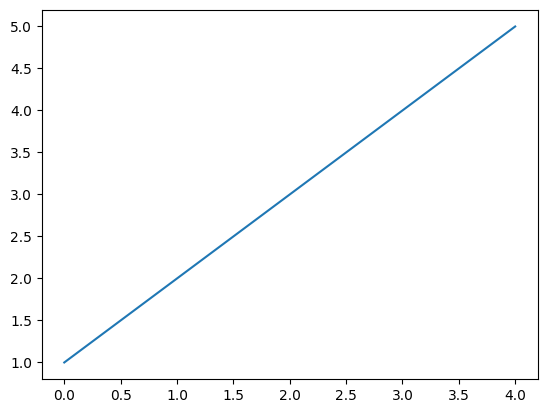

In [ ]:
plt.plot(lst)

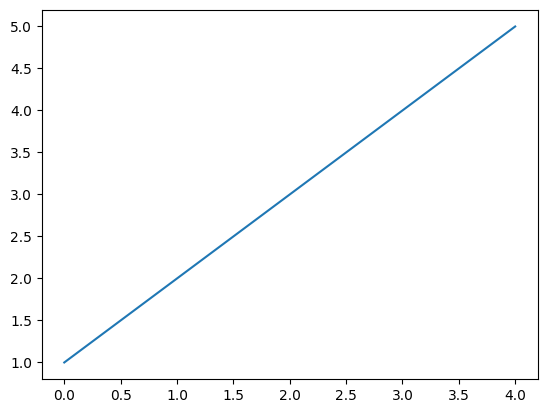

In [ ]:
plt.plot(lst)
plt.show()

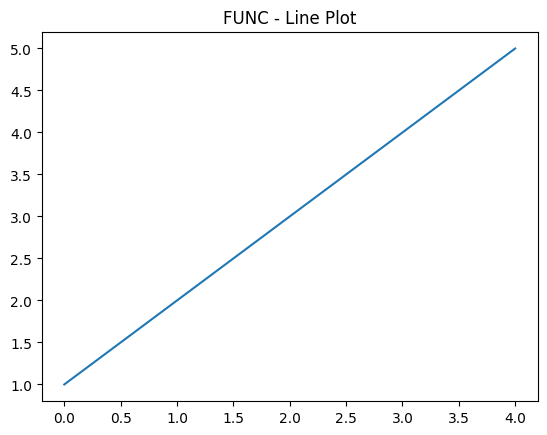

In [ ]:
plt.plot(lst)
plt.title('FUNC - Line Plot')
plt.show()

To increase and decrease title font size

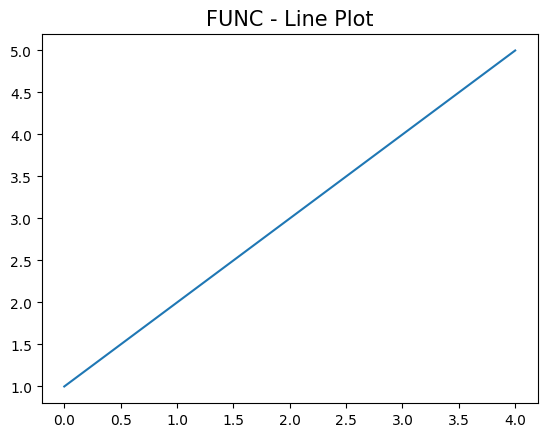

In [ ]:
plt.plot(lst)
plt.title('FUNC - Line Plot', fontsize = 15 )
plt.show()

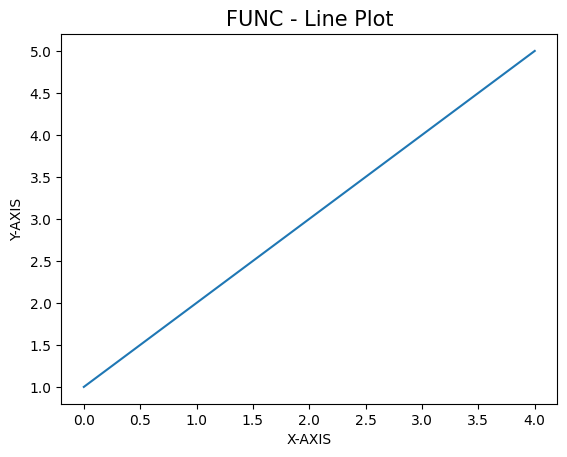

In [ ]:
plt.plot(lst)
plt.title('FUNC - Line Plot', fontsize = 15 )
plt.xlabel('X-AXIS')
plt.ylabel('Y-AXIS')
plt.show()

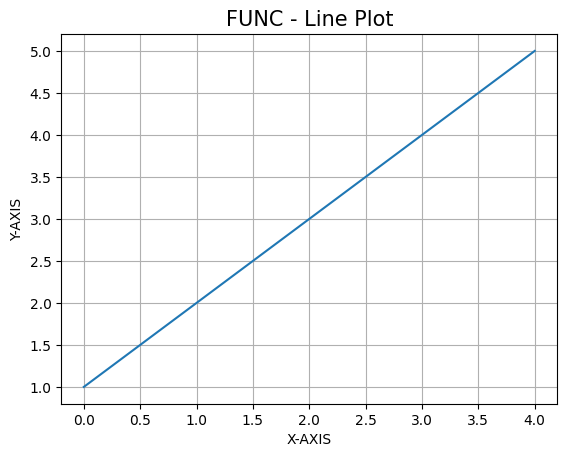

In [ ]:
plt.plot(lst)
plt.title('FUNC - Line Plot', fontsize = 15 )
plt.xlabel('X-AXIS')
plt.ylabel('Y-AXIS')
plt.grid()
plt.show()

/tmp/ipykernel_922/983761772.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


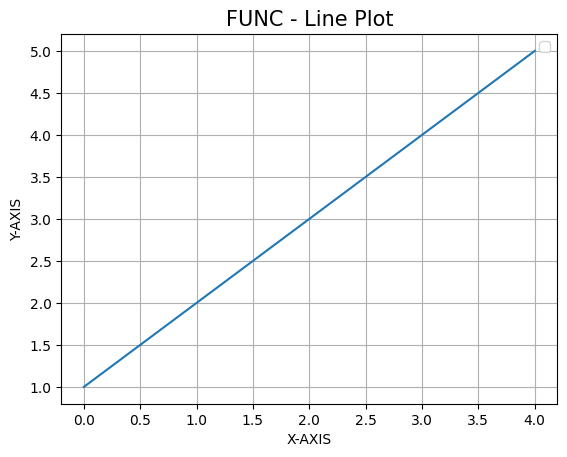

In [ ]:
plt.plot(lst)
plt.title('FUNC - Line Plot', fontsize = 15 )
plt.xlabel('X-AXIS')
plt.ylabel('Y-AXIS')
plt.grid()
plt.legend()
plt.show()

Object oriented way
- Create a base layer - figure
- On top of figure - axis
- On top of axis - ticks
- On top of ticks - artists

In [ ]:
fig = plt.figure()  # 6.4 - width, 4.8 - height
fig

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
fig = plt.figure(figsize = (4, 3))
fig

<Figure size 400x300 with 0 Axes>

<Figure size 400x300 with 0 Axes>

<Axes: >

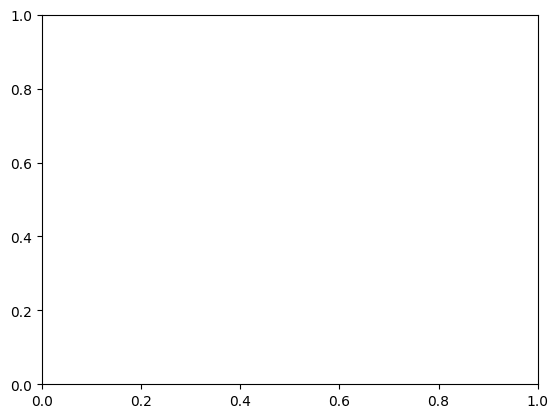

In [ ]:
# fig= plt.figure()
ax = plt.axes()
ax

<Axes: >

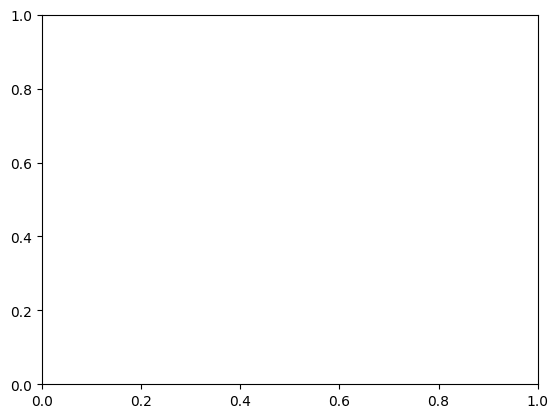

In [ ]:
fig = plt.figure()
ax = plt.axes()
ax

<Axes: >

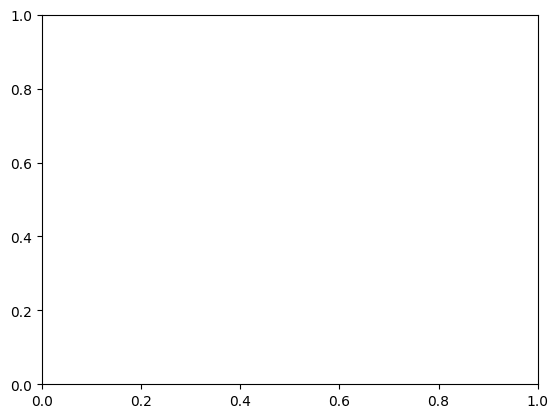

In [ ]:
fig = plt.figure()
fig.add_subplot()
ax

<Axes: >

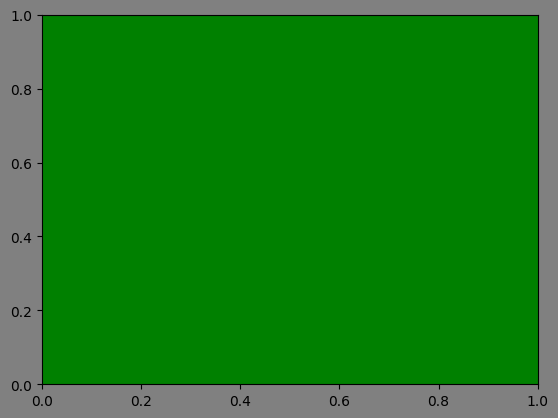

In [ ]:
fig = plt.figure(facecolor = 'grey')
fig.add_subplot(facecolor = 'green')

To create a figure and axis

(<Figure size 640x480 with 1 Axes>, <Axes: >)

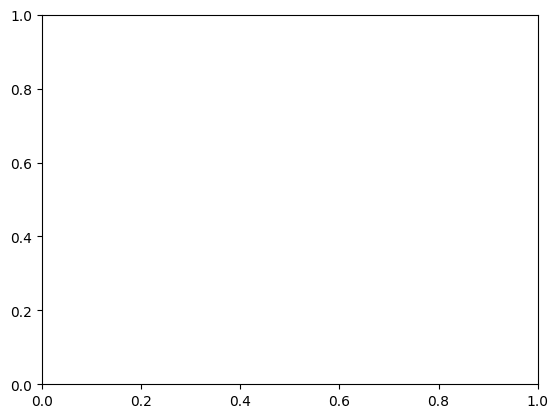

In [ ]:
fig, ax = plt.subplots()
fig, ax

In [ ]:
lst = [10, 20, 30, 40, 50]

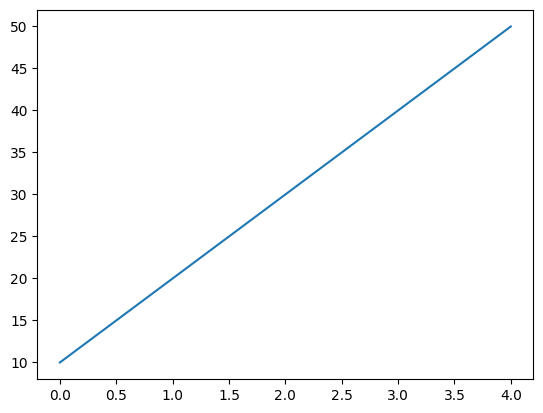

In [ ]:
fig, ax = plt.subplots()
ax.plot(lst)
plt.show()

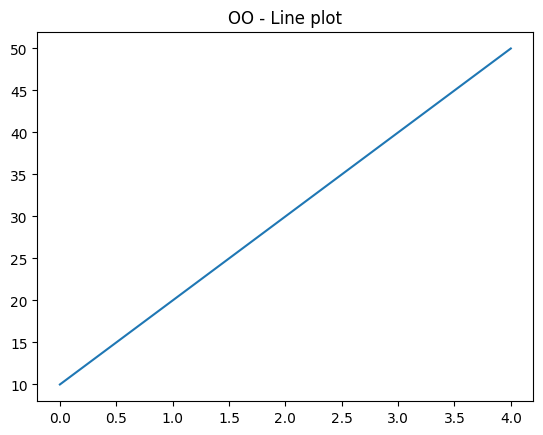

In [ ]:
fig, ax = plt.subplots()
ax.plot(lst)
ax.set_title('OO - Line plot')
plt.show()

In [ ]:
ax.get_title()

'OO - Line plot'

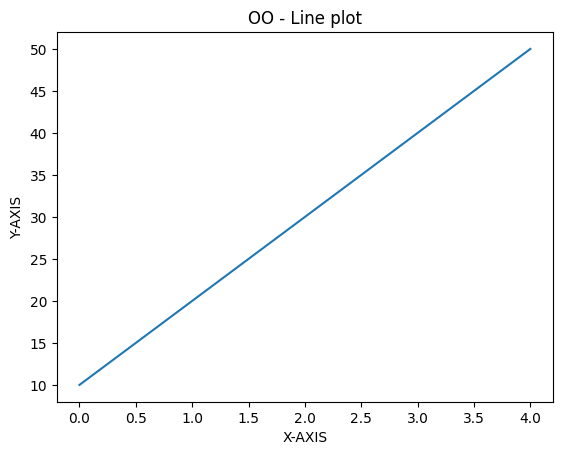

In [ ]:
fig, ax = plt.subplots()
ax.plot(lst)
ax.set_title('OO - Line plot')
ax.set_xlabel('X-AXIS')
ax.set_ylabel('Y-AXIS')
plt.show()

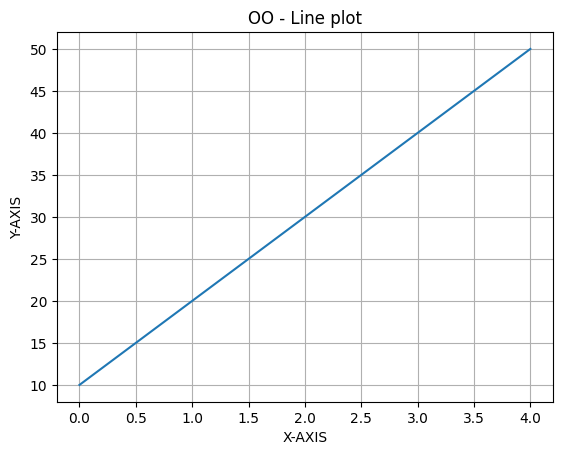

In [ ]:
fig, ax = plt.subplots()
ax.plot(lst)
ax.set_title('OO - Line plot')
ax.set_xlabel('X-AXIS')
ax.set_ylabel('Y-AXIS')
ax.grid()
plt.show()

/tmp/ipykernel_922/206959250.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


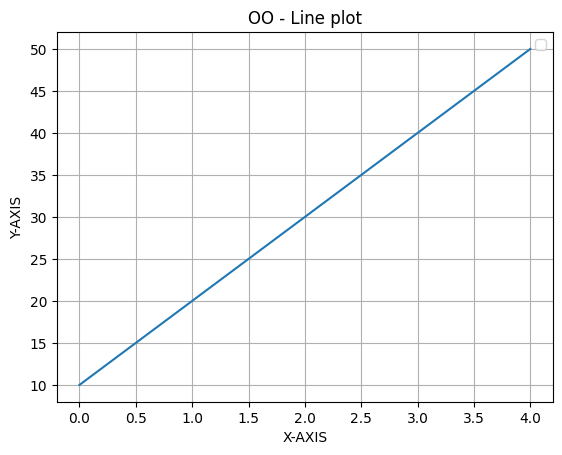

In [ ]:
fig, ax = plt.subplots()
ax.plot(lst)
ax.set_title('OO - Line plot')
ax.set_xlabel('X-AXIS')
ax.set_ylabel('Y-AXIS')
ax.grid()
ax.legend()
plt.show()

Seaborn

In [ ]:
!pip install seaborn

In [ ]:
import seaborn

In [ ]:
import seaborn as sns

Functional way of plotting

In [ ]:
lst = [10, 20, 30, 40, 50]
lst

[10, 20, 30, 40, 50]

<Axes: >

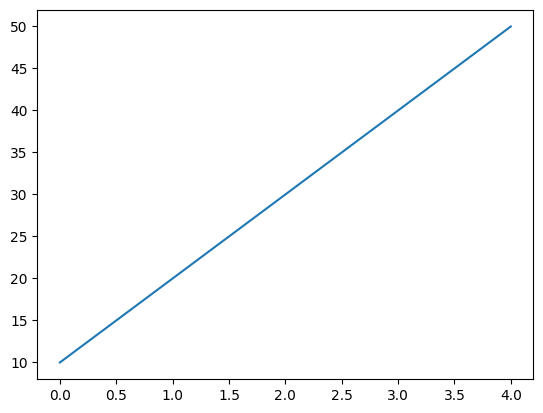

In [ ]:
sns.lineplot(lst)

<Axes: >

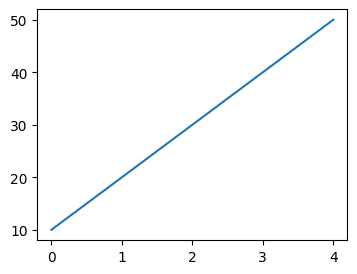

In [ ]:
plt.figure(figsize = (4, 3))
sns.lineplot(lst)

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(lst, columns = ['num'])
df

,num
0,10
1,20
2,30
3,40
4,50


<Axes: ylabel='num'>

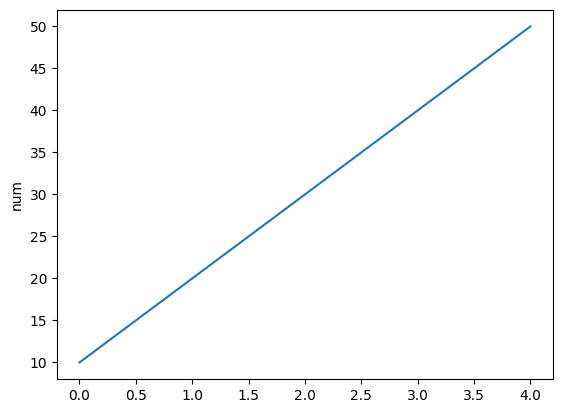

In [ ]:
sns.lineplot(data = df, x = range(5), y = 'num')

Object Oriented way

In [ ]:
import seaborn.objects as so

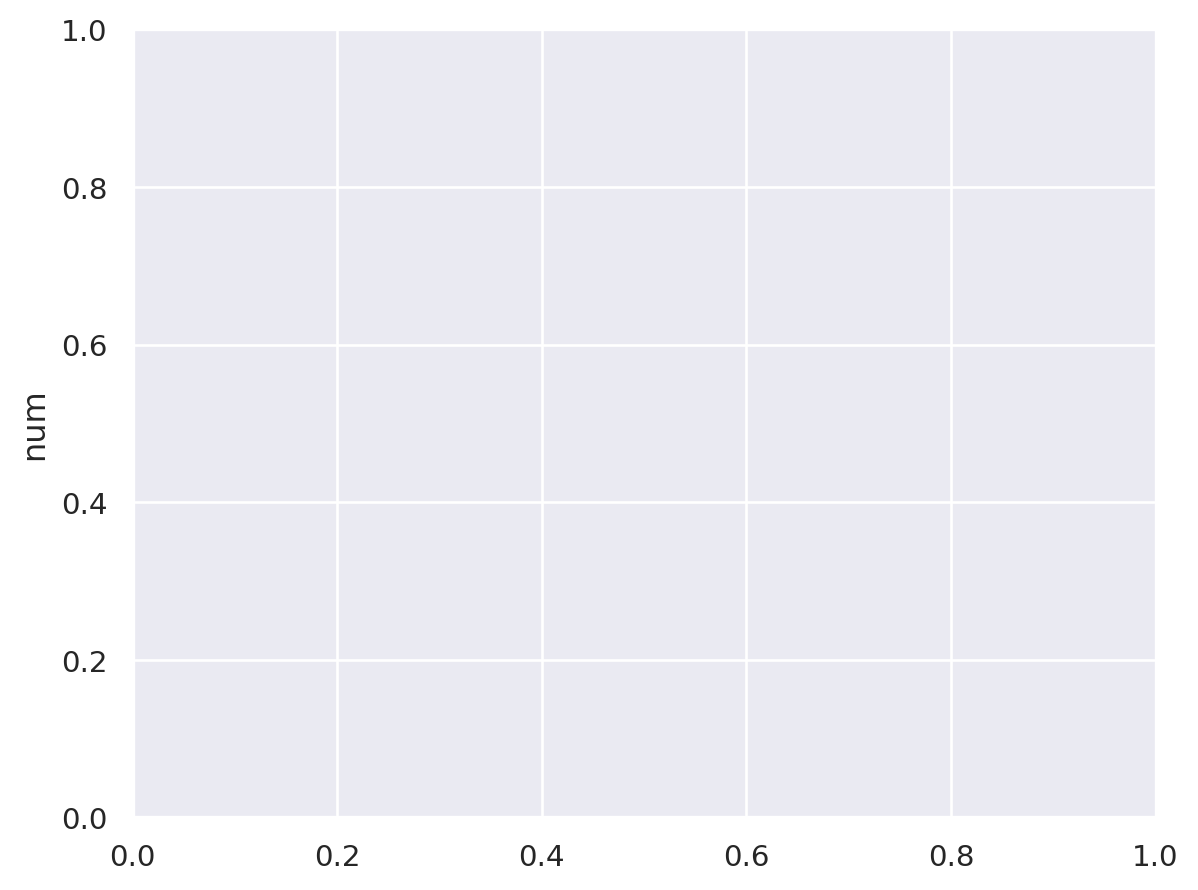

In [ ]:
so.Plot(data = df, x = range(5), y = 'num')

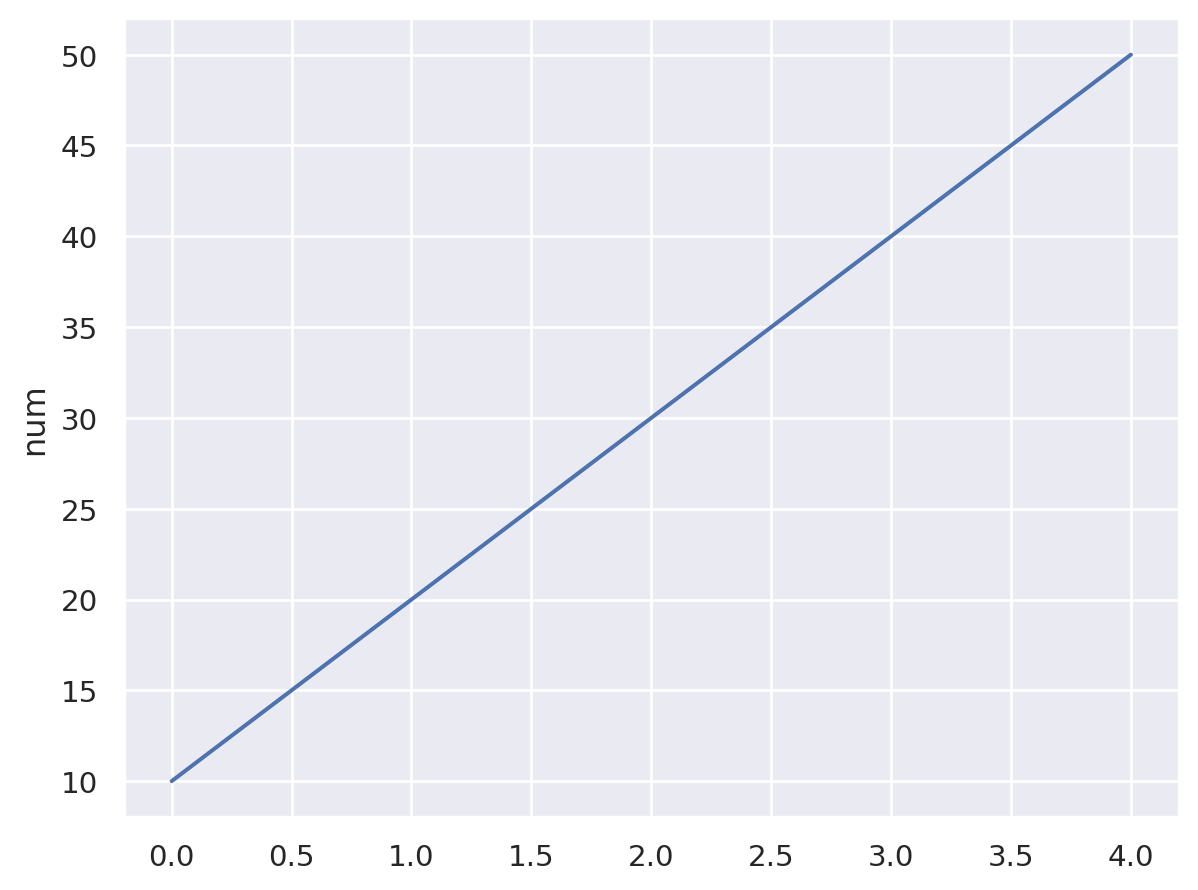

In [ ]:
so.Plot(data = df, x = range(5), y = 'num').add(so.Line())

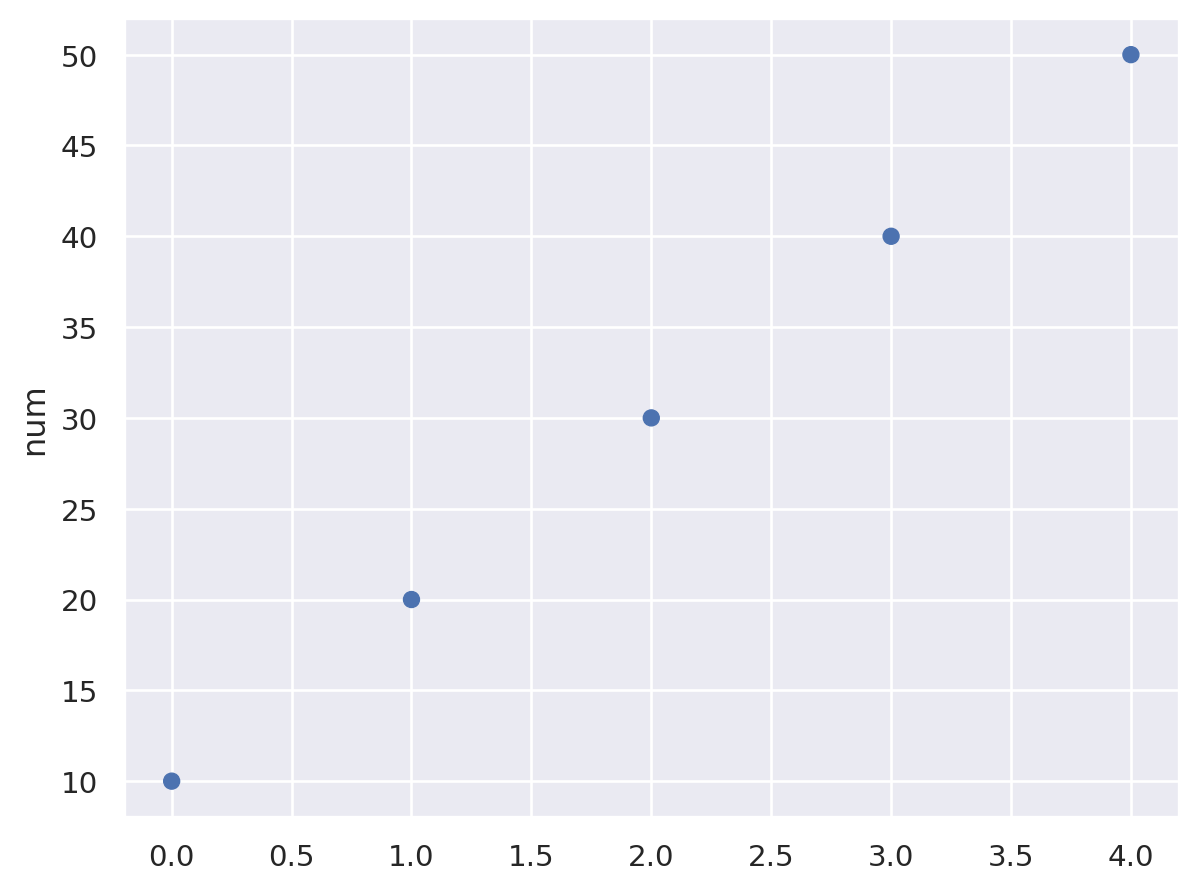

In [ ]:
so.Plot(data = df, x = range(5), y = 'num').add(so.Dot())

Text(0.5, 1.0, 'SNS - Line Plot')

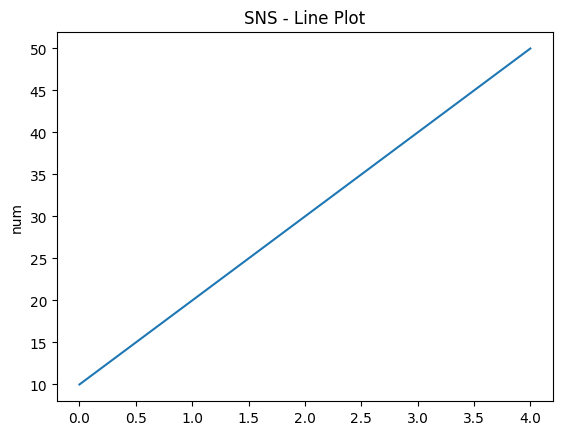

In [ ]:
sns.lineplot(data = df, x = range(5), y = 'num')
plt.title('SNS - Line Plot')

Text(0, 0.5, 'Y-AXIS')

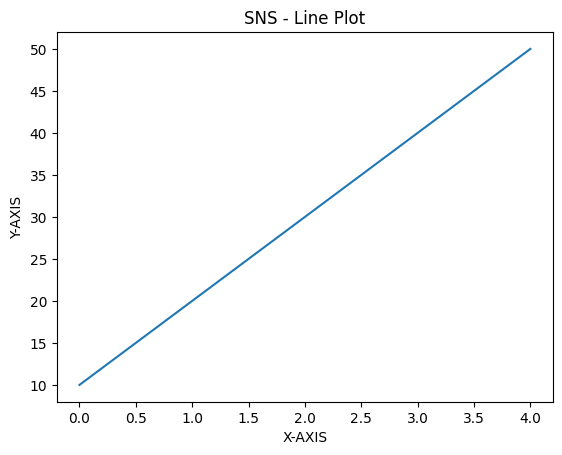

In [ ]:
sns.lineplot(data = df, x = range(5), y = 'num')
plt.title('SNS - Line Plot')
plt.xlabel('X-AXIS')
plt.ylabel('Y-AXIS')

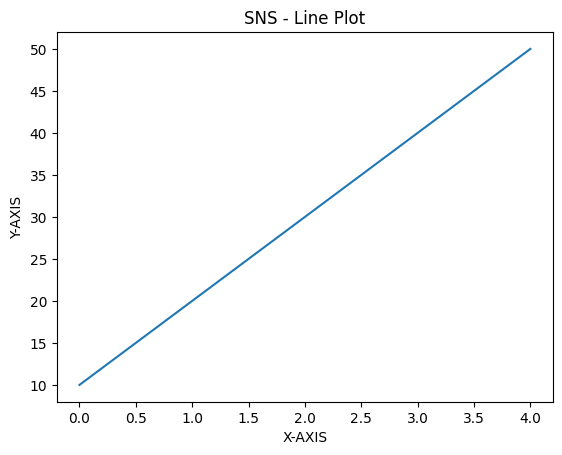

In [ ]:
sns.lineplot(data = df, x = range(5), y = 'num')
plt.title('SNS - Line Plot')
plt.xlabel('X-AXIS')
plt.ylabel('Y-AXIS')
plt.show()

Two line plots on the same axis

In [ ]:
lst1 = [1, 2, 3, 4, 5]
lst2 = [0.5, 2.5, 2.5, 4.5, 4.5]

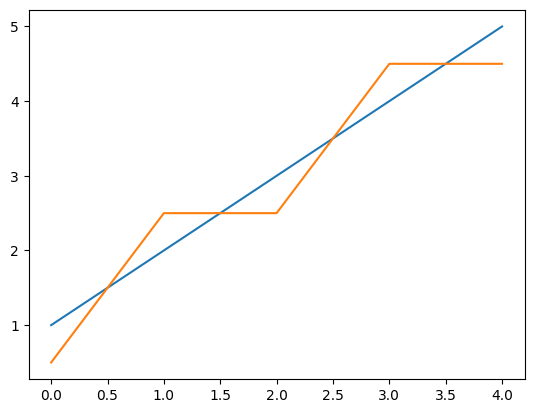

In [ ]:
plt.plot(lst1)
plt.plot(lst2)
plt.show()

two plots on same axis

/tmp/ipykernel_922/3098453757.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


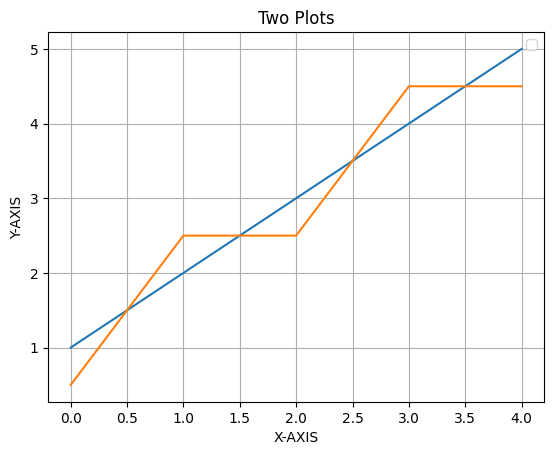

In [ ]:
plt.plot(lst1)
plt.plot(lst2)
plt.title('Two Plots')
plt.xlabel('X-AXIS')
plt.ylabel('Y-AXIS')
plt.grid()
plt.legend()
plt.show()

Two plots on two different axis and on two different figures

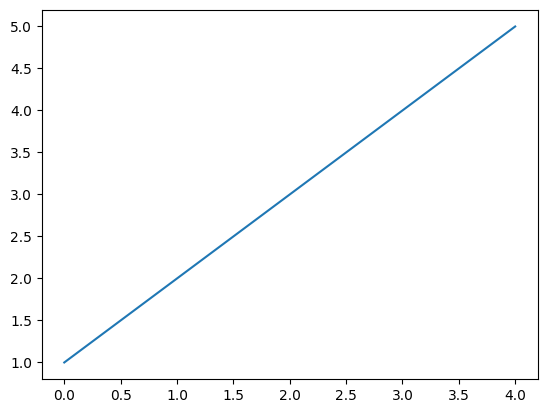

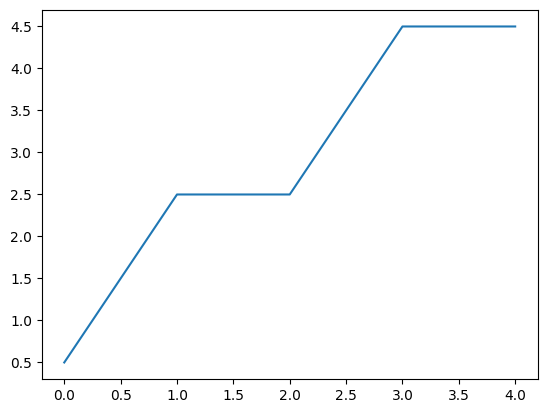

In [ ]:
# NOT INTERESTED at this
plt.plot(lst1)
plt.show()
plt.plot(lst2)
plt.show()

Two plots on two different axis with same figure object
- plt.subplot
  - On the same figure, can create any number of axis
  - plt.subplot(

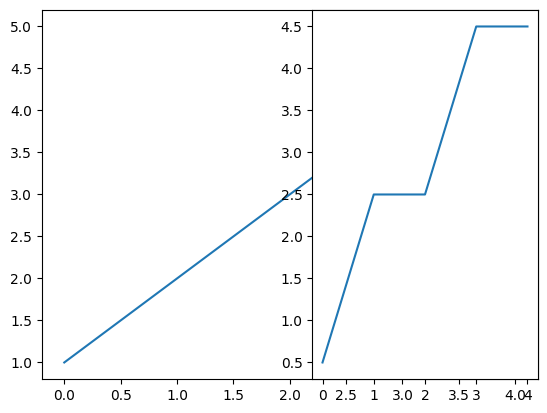

In [ ]:
plt.subplot(1, 1, 1)
plt.plot(lst1)

plt.subplot(1, 2, 2)
plt.plot(lst2)
plt.show()

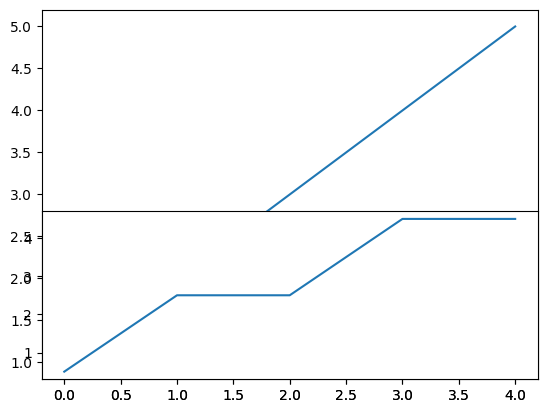

In [ ]:
plt.subplot(1, 1, 1)
plt.plot(lst1)

plt.subplot(2, 1, 2)
plt.plot(lst2)
plt.show()

Object oriented way
- draw two plots on the same figure
- `plt.subplots(nR, nC)`

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

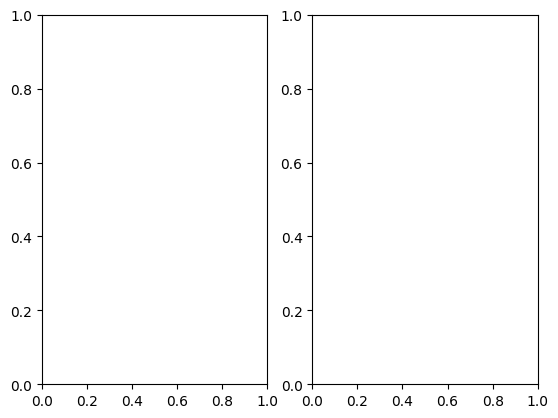

In [ ]:
# One row and two columns
fig, ax = plt.subplots(1, 2)
fig, ax

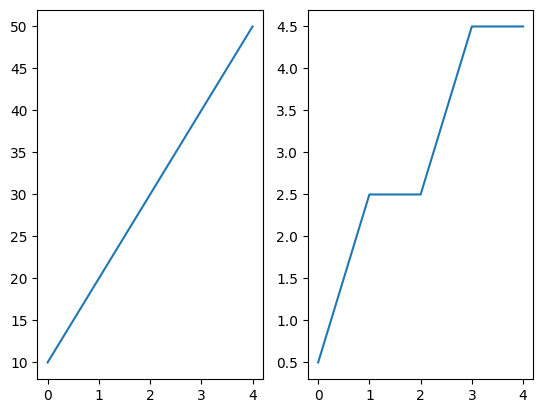

In [ ]:
fig, ax = plt.subplots(1, 2)
ax[0].plot(lst)
ax[1].plot(lst2)

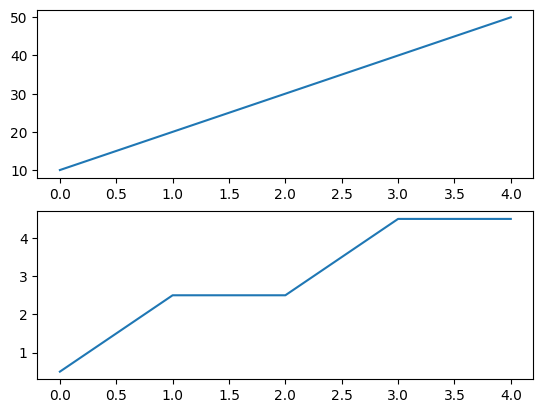

In [ ]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(lst)
ax[1].plot(lst2)

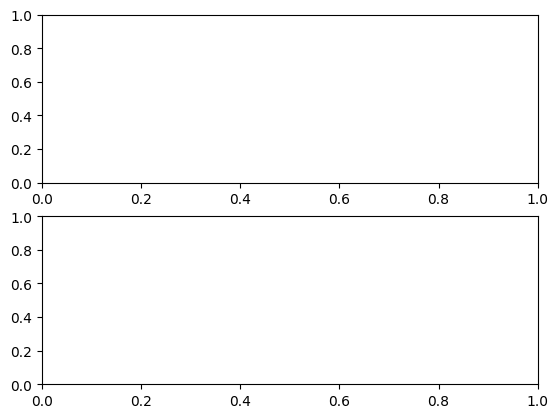

In [ ]:
fig, ax = plt.subplots(2, 1)

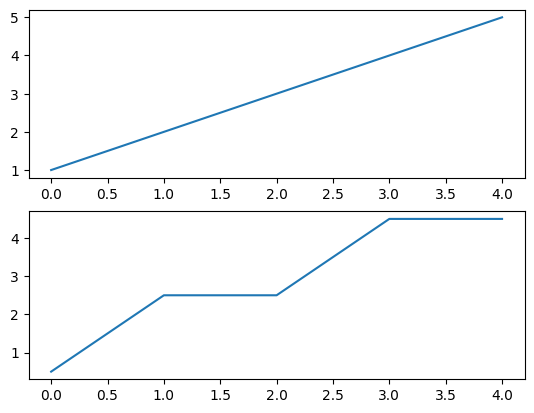

In [ ]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(lst1)
ax[1].plot(lst2)

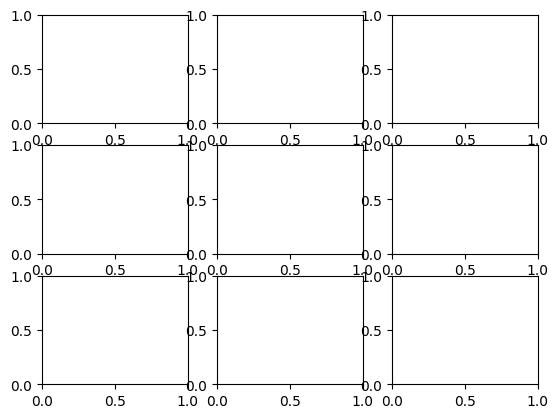

In [ ]:
fig, ax = plt.subplots(3, 3)

Text(0.5, 1.0, '[2, 2]')

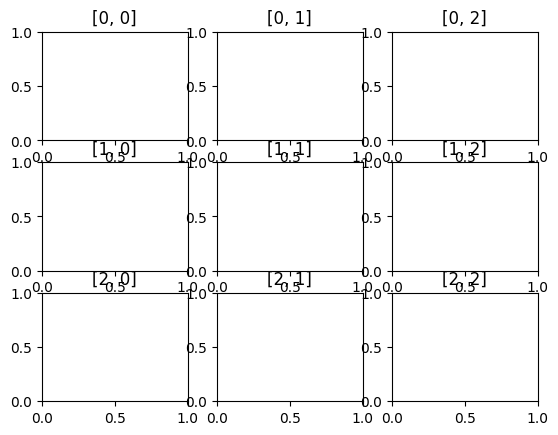

In [ ]:
fig, ax = plt.subplots(3, 3)
fig, ax
ax[0, 0].set_title('[0, 0]')
ax[0, 1].set_title('[0, 1]')
ax[0, 2].set_title('[0, 2]')
ax[1, 0].set_title('[1, 0]')
ax[1, 1].set_title('[1, 1]')
ax[1, 2].set_title('[1, 2]')
ax[2, 0].set_title('[2, 0]')
ax[2, 1].set_title('[2, 1]')
ax[2, 2].set_title('[2, 2]')

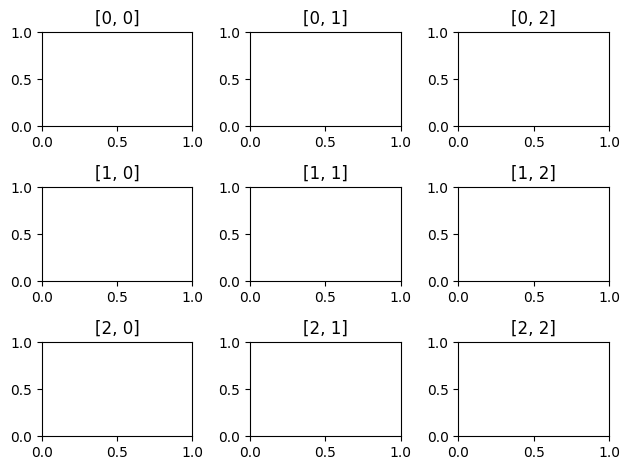

In [ ]:
fig, ax = plt.subplots(3, 3)
fig, ax
ax[0, 0].set_title('[0, 0]')
ax[0, 1].set_title('[0, 1]')
ax[0, 2].set_title('[0, 2]')
ax[1, 0].set_title('[1, 0]')
ax[1, 1].set_title('[1, 1]')
ax[1, 2].set_title('[1, 2]')
ax[2, 0].set_title('[2, 0]')
ax[2, 1].set_title('[2, 1]')
ax[2, 2].set_title('[2, 2]')
plt.tight_layout()
plt.show()

/tmp/ipykernel_922/3112356986.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


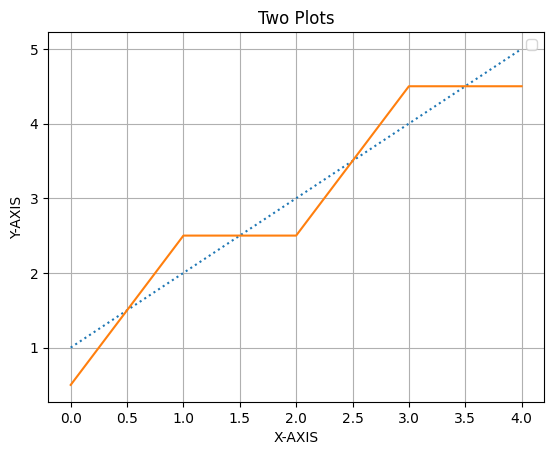

In [ ]:
plt.plot(lst1, linestyle = ':')
plt.plot(lst2, linestyle = '-')
plt.title('Two Plots')
plt.xlabel('X-AXIS')
plt.ylabel('Y-AXIS')
plt.grid()
plt.legend()
plt.show()

#04-09-2026

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
data = sns.load_dataset('tips')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
data.isna.sum

AttributeError: 'function' object has no attribute 'sum'

In [ ]:
data.duplicated().sum()

np.int64(1)

In [ ]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
data.describe(include = 'all')

,total_bill,tip,sex,smoker,day,time,size
count,243.000000,243.000000,243,243,243,243,243.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.813868,3.002387,NaN,NaN,NaN,NaN,2.572016
std,8.910071,1.385002,NaN,NaN,NaN,NaN,0.952356
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.380000,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.810000,2.920000,NaN,NaN,NaN,NaN,2.000000
75%,24.175000,3.575000,NaN,NaN,NaN,NaN,3.000000


In [ ]:
data.describe(percentiles = [0.05, 0.10, 0.15, 0.20, 0.25, 0.5, 0.75])

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
5%,9.555000,1.440000,2.000000
10%,10.340000,1.500000,2.000000
15%,11.596000,1.736000,2.000000
20%,12.624000,2.000000,2.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000


In [ ]:
data.describe(percentiles = [0.25, 0.5, 0.75, 0.80, 0.85, 0.90, 0.95])

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
80%,26.202000,4.000000,3.000000
85%,28.844000,4.197000,4.000000
90%,32.290000,5.000000,4.000000


**How does the total bill amount trend over time in the dataset?**

- How total bill changes, as time progresses.

In [ ]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Lineplot - To plot Timeseries

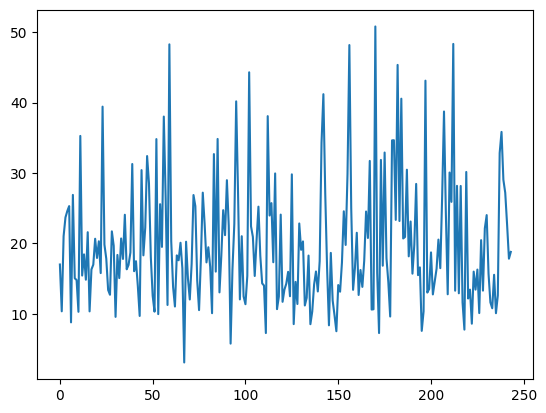

In [ ]:
# matplotlib
plt.plot(data['total_bill'])
plt.show()

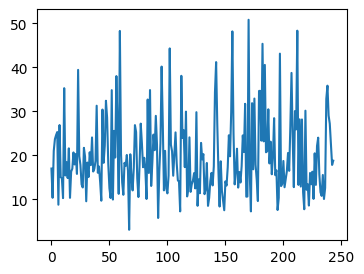

In [ ]:
plt.figure(figsize = (4, 3))
plt.plot(data['total_bill'])

(width, height)

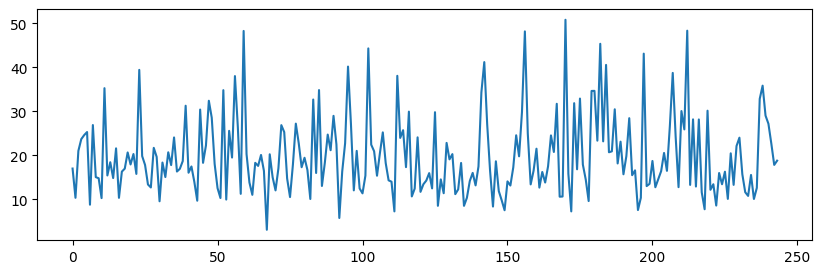

In [ ]:
plt.figure(figsize = (10, 3))
plt.plot(data['total_bill'])

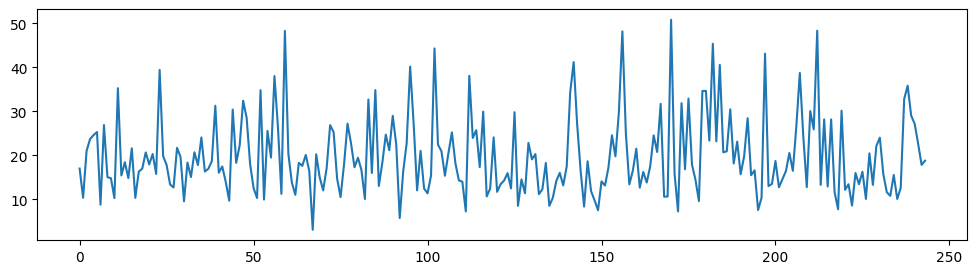

In [ ]:
plt.figure(figsize = (12, 3))
plt.plot(data['total_bill'])

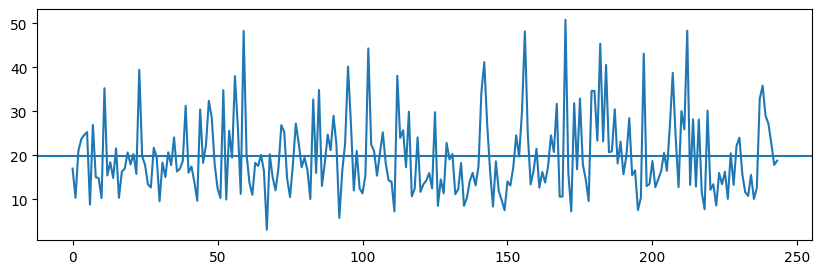

In [ ]:
plt.figure(figsize = (10, 3))
plt.plot(data['total_bill'])
plt.axhline(data['total_bill'].mean())

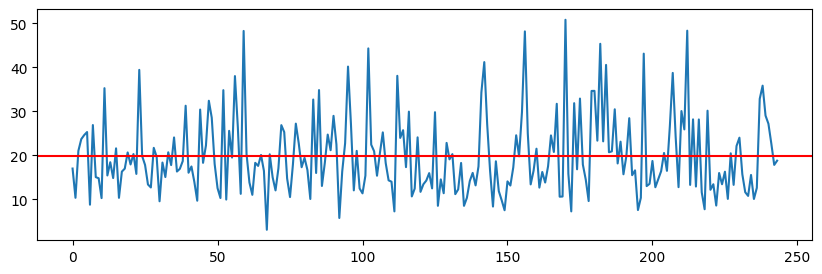

In [ ]:
plt.figure(figsize = (10, 3))
plt.plot(data['total_bill'])
plt.axhline(data['total_bill'].mean(), color = 'r')

<Axes: ylabel='total_bill'>

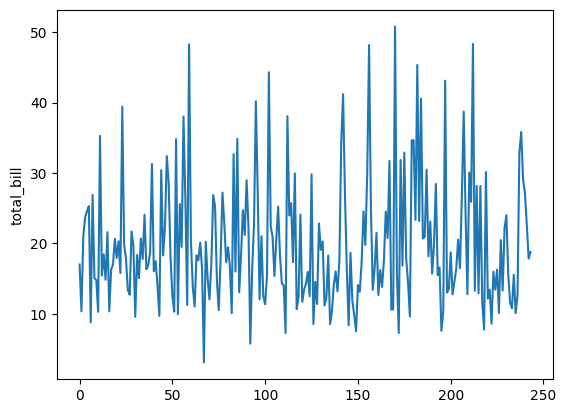

In [ ]:
sns.lineplot(data['total_bill']) # not recommended

<Axes: ylabel='total_bill'>

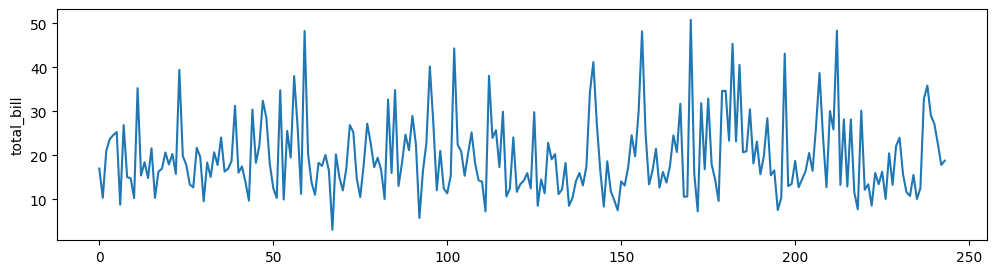

In [ ]:
plt.figure(figsize = (12, 3))
sns.lineplot(data['total_bill'])

<Axes: ylabel='total_bill'>

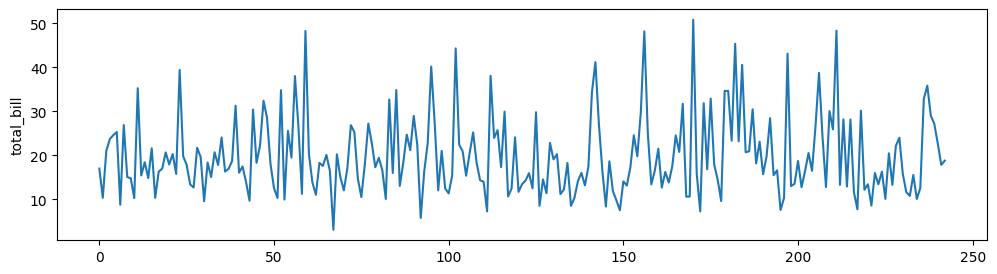

In [ ]:
plt.figure(figsize = (12, 3))
sns.lineplot(data = data, y = 'total_bill', x = range(data.shape[0]))

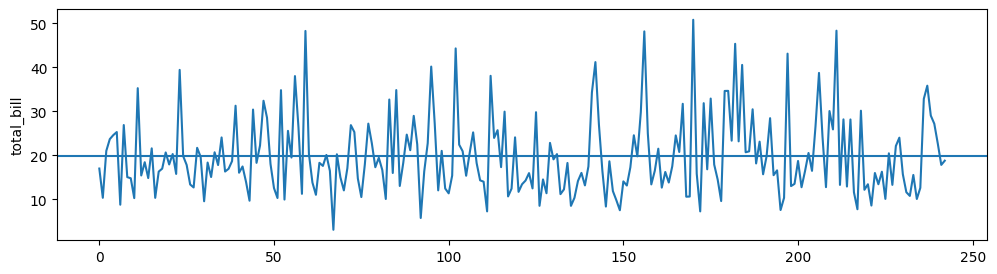

In [ ]:
plt.figure(figsize = (12, 3))
sns.lineplot(data = data, y = 'total_bill', x = range(data.shape[0]))
plt.axhline(data['total_bill'].mean())

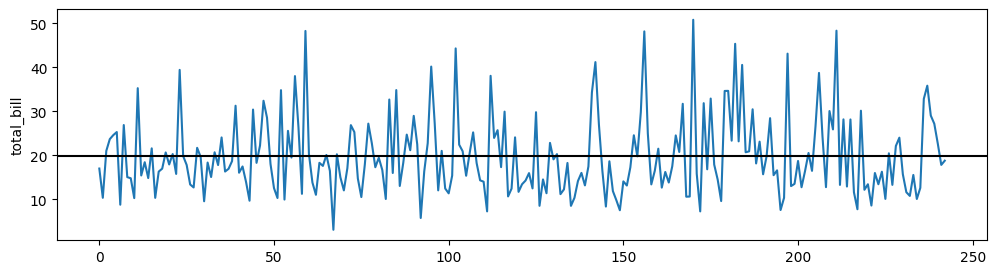

In [ ]:
plt.figure(figsize = (12, 3))
sns.lineplot(data = data, y = 'total_bill', x = range(data.shape[0]))
plt.axhline(data['total_bill'].mean(), color = 'k')

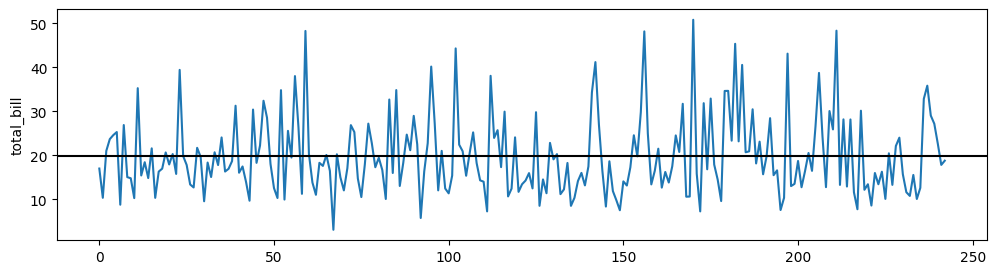

In [ ]:
plt.figure(figsize = (12, 3))
sns.lineplot(data = data, y = 'total_bill', x = range(data.shape[0]))
plt.axhline(data['total_bill'].mean(), color = 'k')
plt.show()

**Do the trends followed by thee total bill and tip amounts exhibit similar patterns?**

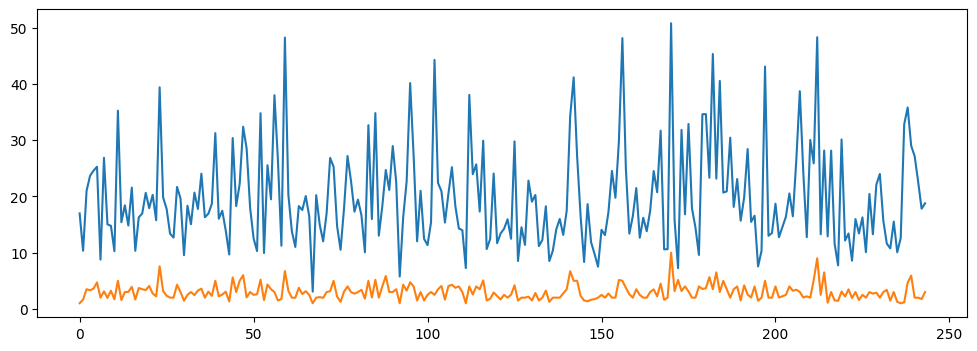

In [ ]:
plt.figure(figsize = (12, 4))
plt.plot(data['total_bill'])
plt.plot(data['tip'])
plt.show()

In [ ]:
plt.figure(figsize = (12, 4))
sns.lineplot(data = data, x = range(data.shape[0], y = 'total_bill'))
sns.lineplot(data = data, x = range(data.shape[0], y = 'tip'))
plt.show()

TypeError: range() takes no keyword arguments

<Figure size 1200x400 with 0 Axes>

**How do total bill trends differ between male and female customers?**

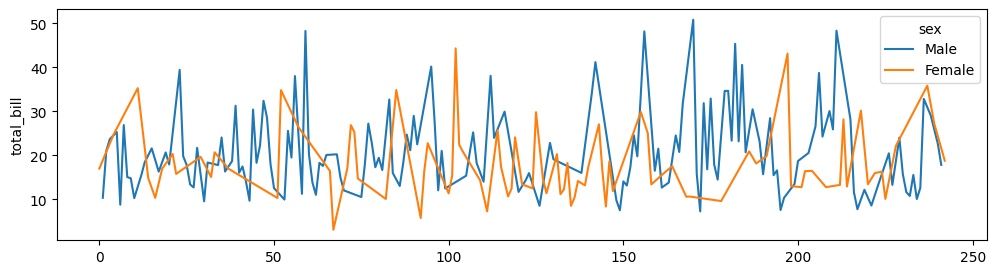

In [ ]:
plt.figure(figsize = (12, 3))
sns.lineplot(data = data, x = range(data.shape[0]), y = 'total_bill', hue = 'sex')
plt.show()

<Axes: xlabel='sex', ylabel='total_bill'>

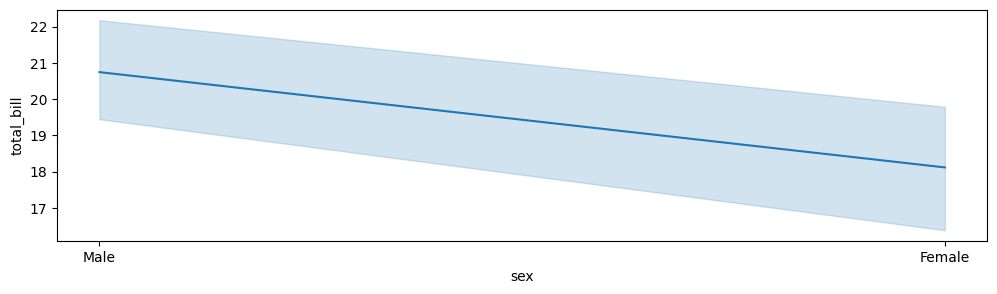

In [ ]:
plt.figure(figsize = (12, 3))
sns.lineplot(data = data, y = 'total_bill', x = 'sex')


In [ ]:
# Total Bill and Sex
gb = data.groupby('sex')['total_bill']
gb

/tmp/ipykernel_2161/3708522439.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = data.groupby('sex')['total_bill']


In [ ]:
list(gb)

[('Male',
  1      10.34
  2      21.01
  3      23.68
  5      25.29
  6       8.77
         ...  
  236    12.60
  237    32.83
  239    29.03
  241    22.67
  242    17.82
  Name: total_bill, Length: 157, dtype: float64),
 ('Female',
  0      16.99
  4      24.59
  11     35.26
  14     14.83
  16     10.33
         ...  
  226    10.09
  229    22.12
  238    35.83
  240    27.18
  243    18.78
  Name: total_bill, Length: 86, dtype: float64)]

In [ ]:
lgb = list(gb)
lgb

[('Male',
  1      10.34
  2      21.01
  3      23.68
  5      25.29
  6       8.77
         ...  
  236    12.60
  237    32.83
  239    29.03
  241    22.67
  242    17.82
  Name: total_bill, Length: 157, dtype: float64),
 ('Female',
  0      16.99
  4      24.59
  11     35.26
  14     14.83
  16     10.33
         ...  
  226    10.09
  229    22.12
  238    35.83
  240    27.18
  243    18.78
  Name: total_bill, Length: 86, dtype: float64)]

In [ ]:
male_tb = lgb[0][1]
male_tb.head()

,total_bill
1,10.34
2,21.01
3,23.68
5,25.29
6,8.77


In [ ]:
female_tb = lgb[1][1]
female_tb.head()

,total_bill
0,16.99
4,24.59
11,35.26
14,14.83
16,10.33


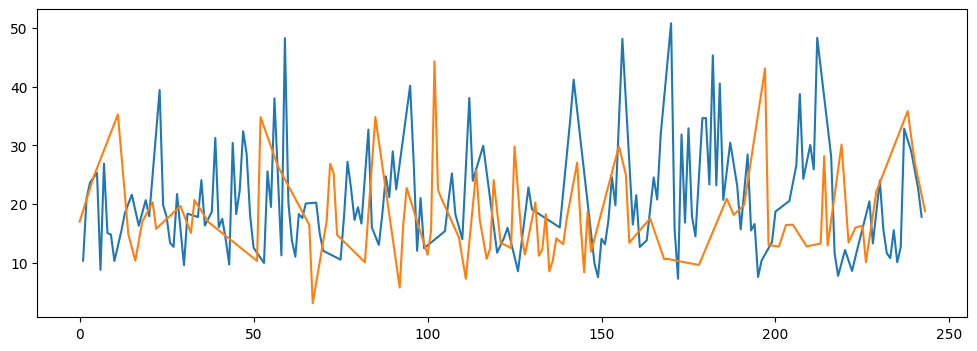

In [ ]:
plt.figure(figsize = (12, 4))
plt.plot(male_tb)
plt.plot(female_tb)
plt.show()

**What is the distribution of total bill amounts among customers?**
- Numeric variables
  - Histogram
  - Box Plot

MATPLOTLIB

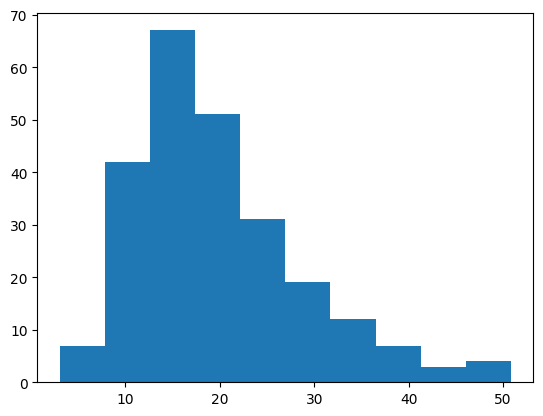

In [ ]:
plt.hist(data['total_bill'])
plt.show()

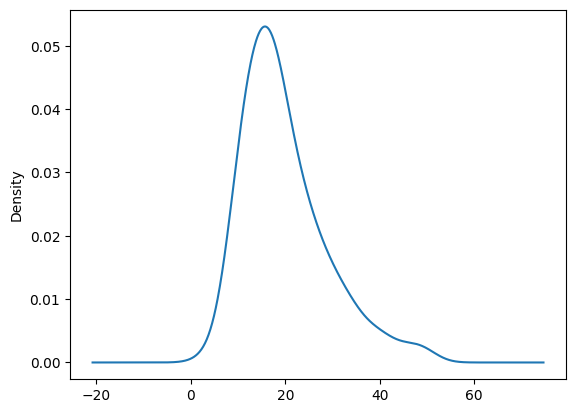

In [ ]:
(data['total_bill']).plot(kind = 'kde')
plt.show()

Seaborn

<Axes: xlabel='total_bill', ylabel='Count'>

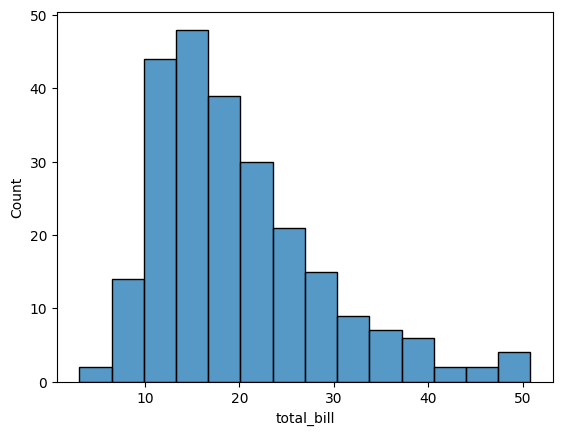

In [ ]:
sns.histplot(data = data, x = 'total_bill')

<Axes: xlabel='total_bill', ylabel='Count'>

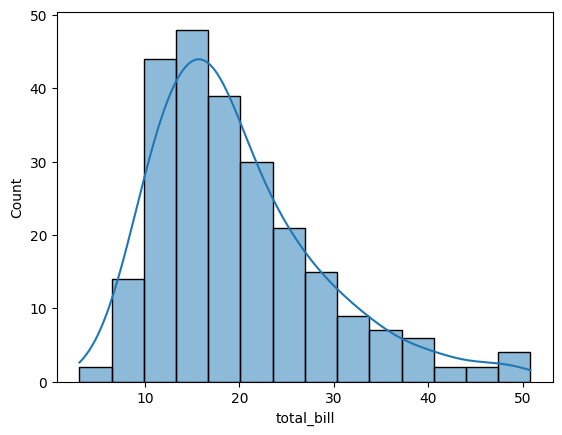

In [ ]:
sns.histplot(data = data, x = 'total_bill', kde = True)

What is the distribution of tip amounts among customers, and are there any underlying patterns a

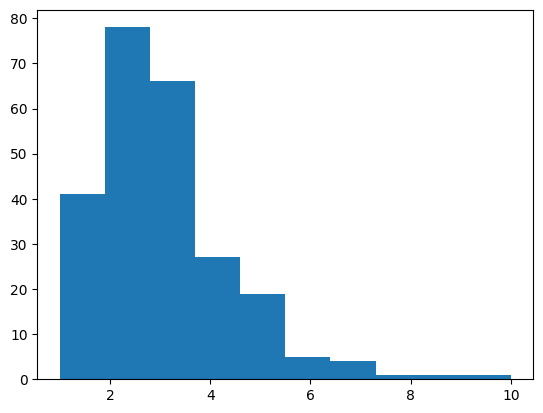

In [ ]:
plt.hist(data['tip'])
plt.show()

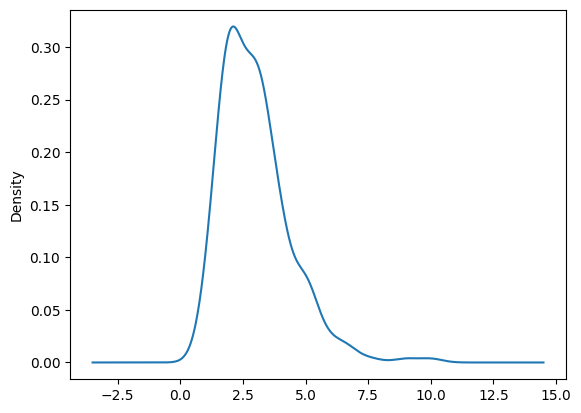

In [ ]:
data['tip'].plot(kind = 'kde')
plt.show()

<Axes: xlabel='tip', ylabel='Count'>

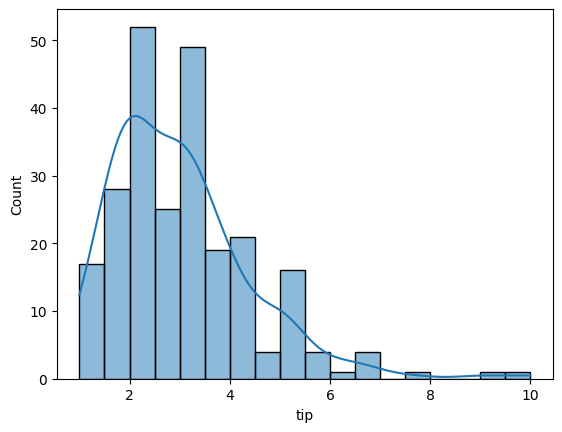

In [ ]:
sns.histplot(data= data, x = 'tip', kde = True)

<Axes: xlabel='tip', ylabel='Density'>

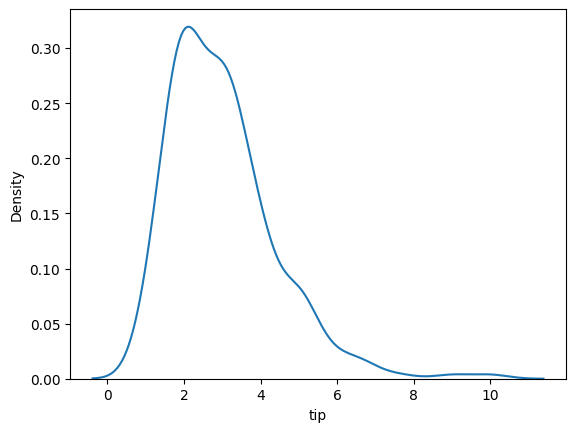

In [ ]:
sns.kdeplot(data= data, x = 'tip')

BOX PLOT

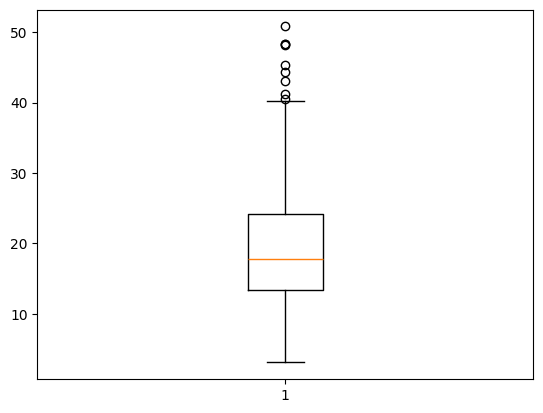

In [ ]:
plt.boxplot(data['total_bill'])
plt.show()

**How does the distribution of total bill amounts differ between male and female customers?**

<Axes: ylabel='total_bill'>

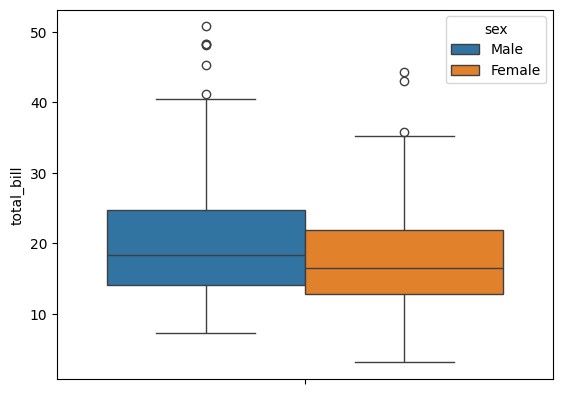

In [ ]:
sns.boxplot(data = data, y = 'total_bill', hue = 'sex')

<Axes: xlabel='total_bill', ylabel='Count'>

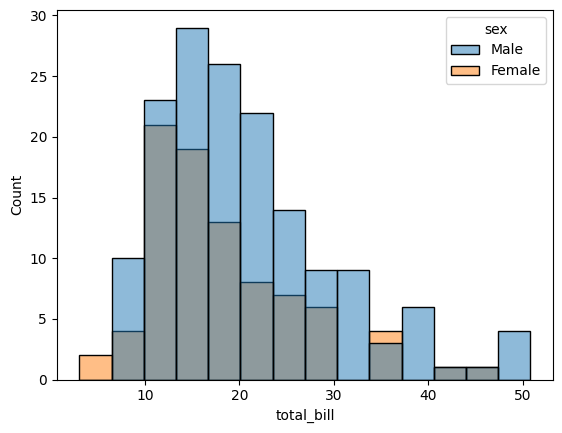

In [ ]:
sns.histplot(data = data, x = 'total_bill', hue = 'sex')

<Axes: xlabel='total_bill', ylabel='Density'>

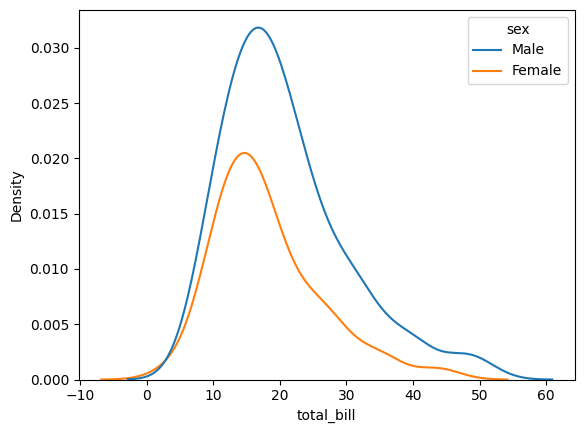

In [ ]:
sns.kdeplot(data = data, x = 'total_bill', hue = 'sex')

<Axes: xlabel='total_bill'>

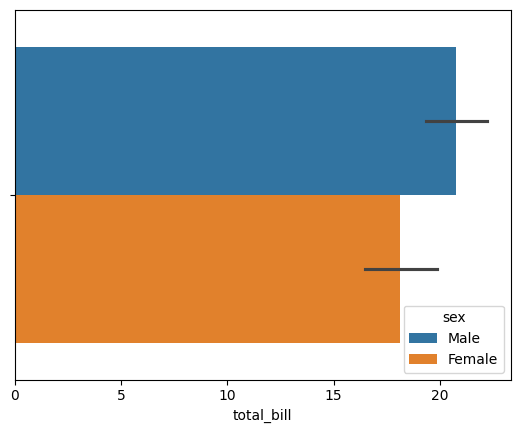

In [ ]:
sns.barplot(data = data, x = 'total_bill', hue = 'sex')

<Axes: ylabel='total_bill'>

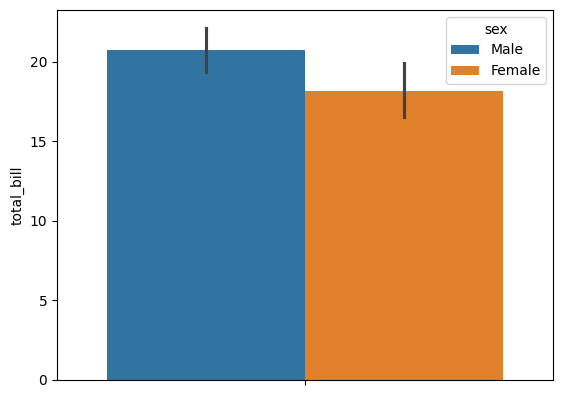

In [ ]:
sns.barplot(data = data, y = 'total_bill', hue = 'sex')

{'whiskers': [<matplotlib.lines.Line2D at 0x7fef81ec9450>,
 'caps': [<matplotlib.lines.Line2D at 0x7fef81ec96d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fef81ec9310>],
 'medians': [<matplotlib.lines.Line2D at 0x7fef81ec9950>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fef81ec9a90>],
 'means': []}

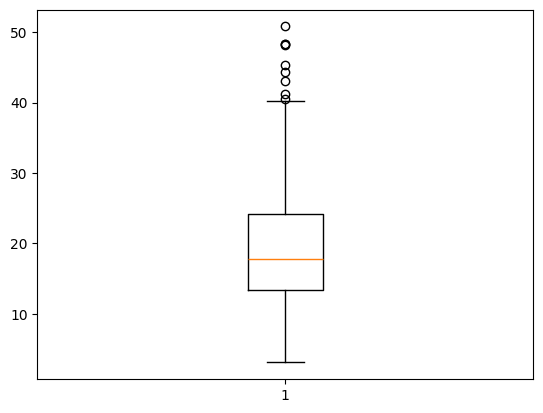

In [ ]:
plt.boxplot(x = data['total_bill'])

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = sns.load_dataset('tips')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**What are the differences in range of `total bill` amounts between `male and female` customers?**
- total_bill - NUM
- sex- CAT

<Axes: ylabel='total_bill'>

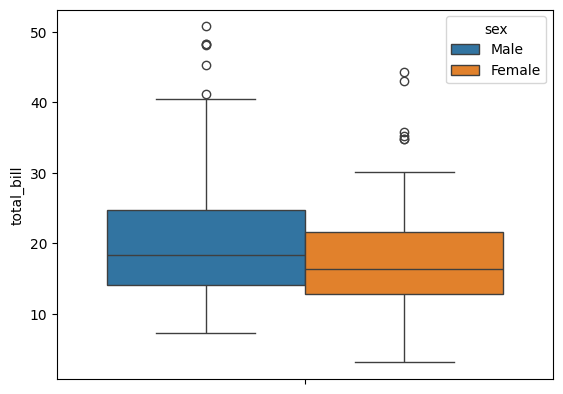

In [3]:
# Boxplot
sns.boxplot(data = data, y = 'total_bill', hue = 'sex')

<Axes: ylabel='total_bill'>

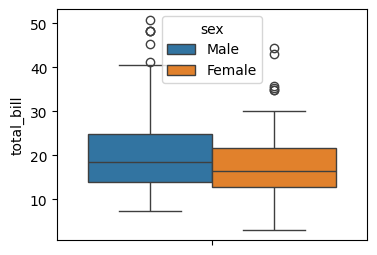

In [4]:
# Boxplot
plt.figure(figsize = (4, 3))
sns.boxplot(data = data, y = 'total_bill', hue = 'sex')

<Axes: xlabel='Count', ylabel='total_bill'>

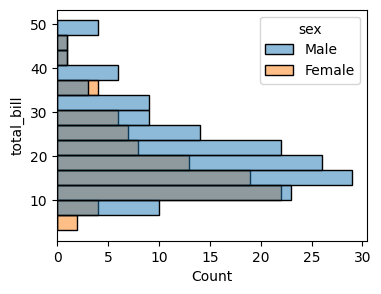

In [5]:
plt.figure(figsize = (4, 3))
sns.histplot(data = data, y = 'total_bill', hue = 'sex')

<Axes: xlabel='total_bill', ylabel='Count'>

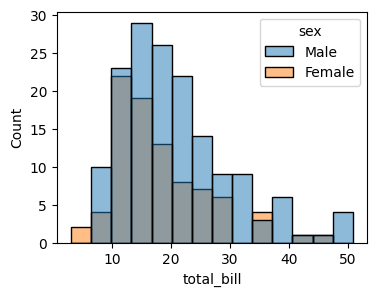

In [6]:
plt.figure(figsize = (4, 3))
sns.histplot(data = data, x = 'total_bill', hue = 'sex')

<Axes: xlabel='Density', ylabel='total_bill'>

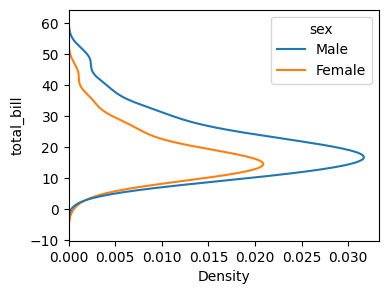

In [7]:
plt.figure(figsize = (4, 3))
sns.kdeplot(data = data, y = 'total_bill', hue = 'sex')

<Axes: xlabel='total_bill', ylabel='Density'>

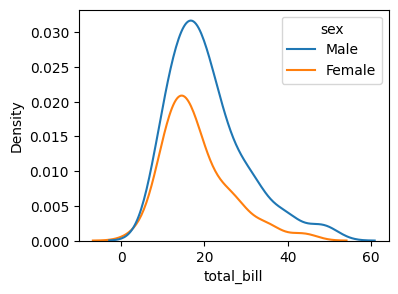

In [9]:
plt.figure(figsize = (4, 3))
sns.kdeplot(data = data, x = 'total_bill', hue = 'sex')

<Axes: xlabel='total_bill'>

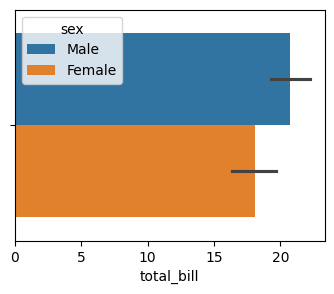

In [10]:
plt.figure(figsize = (4, 3))
sns.barplot(data = data, x = 'total_bill', hue = 'sex')

<Axes: ylabel='total_bill'>

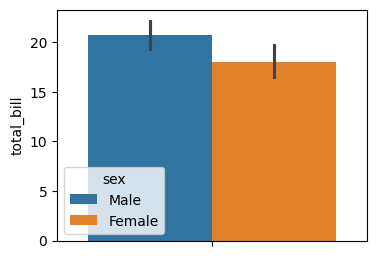

In [11]:
plt.figure(figsize = (4, 3))
sns.barplot(data = data, y = 'total_bill', hue = 'sex')

**How do the total bill amounts differ between male and female customers, and what impact does the time of day (lunch or dinner) have on it?**

- total_bill - NUM
- Sex, time - CAT

<Axes: xlabel='time', ylabel='total_bill'>

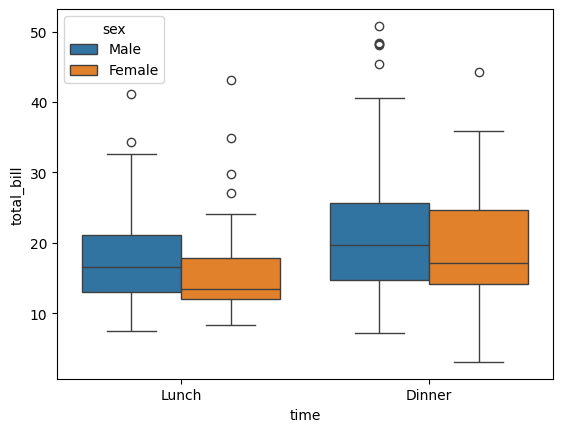

In [12]:
sns.boxplot(data = data, y = 'total_bill', x = 'time', hue = 'sex')

<Axes: xlabel='time', ylabel='total_bill'>

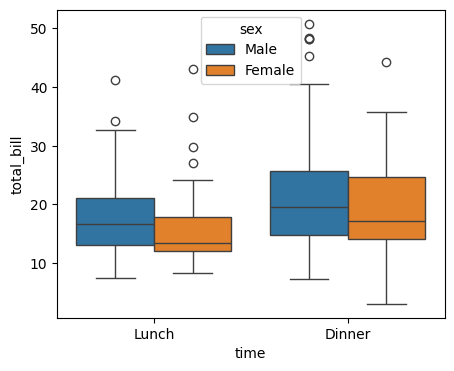

In [14]:
plt.figure(figsize = (5, 4))
sns.boxplot(data = data, y = 'total_bill', x = 'time', hue = 'sex')

<Axes: xlabel='time', ylabel='total_bill'>

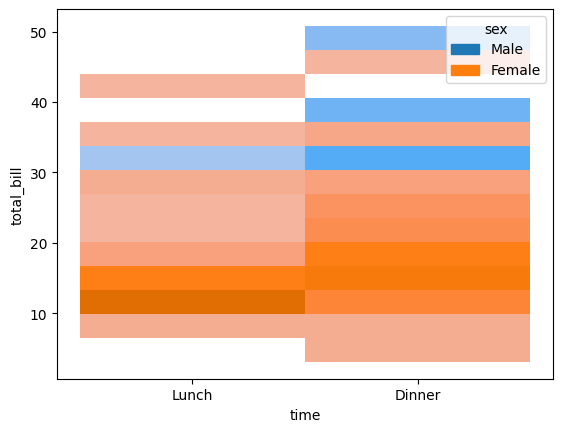

In [15]:
sns.histplot(data = data, y = 'total_bill', x = 'time', hue = 'sex')

<Axes: xlabel='total_bill', ylabel='time'>

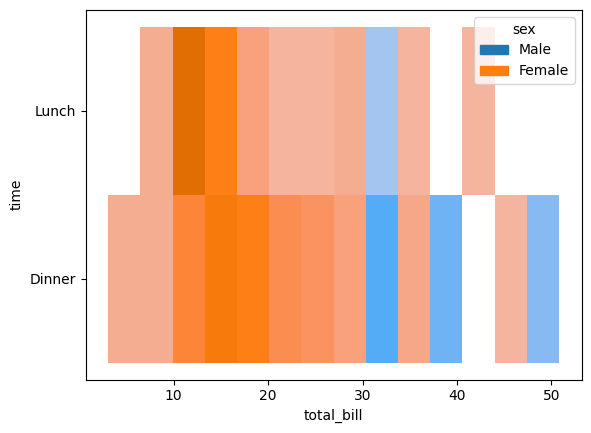

In [16]:
sns.histplot(data = data, x = 'total_bill', y = 'time', hue = 'sex')

<Axes: xlabel='time', ylabel='total_bill'>

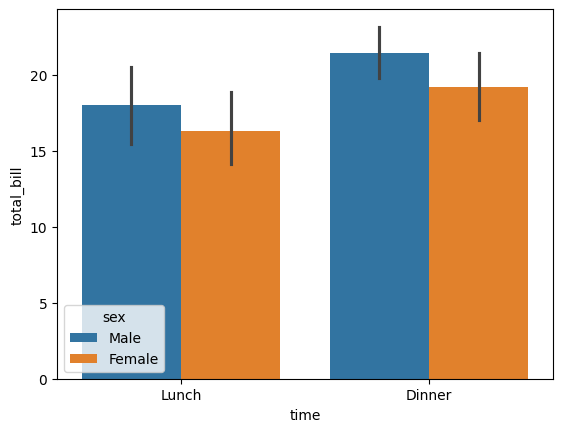

In [17]:
sns.barplot(data = data, y = 'total_bill', x = 'time', hue = 'sex')

<Axes: xlabel='time', ylabel='total_bill'>

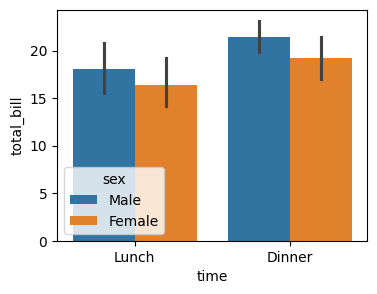

In [18]:
plt.figure(figsize = (4, 3))
sns.barplot(data = data, y = 'total_bill', x = 'time', hue = 'sex')


/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


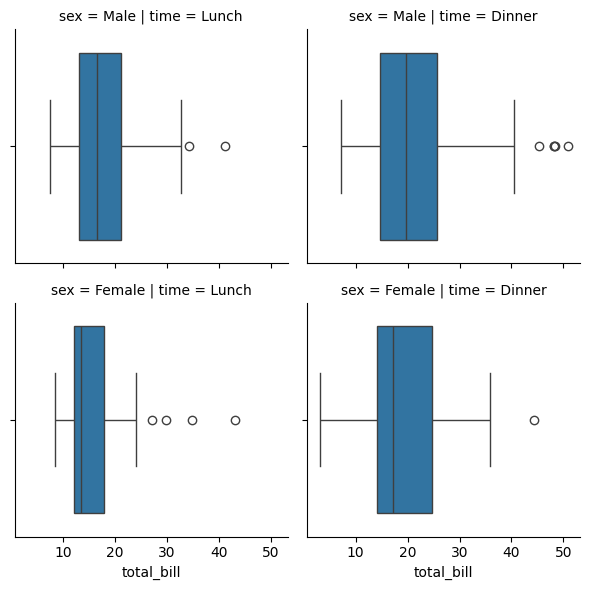

In [22]:
pl = sns.FacetGrid(data = data, row = 'sex', col = 'time')
pl.map(sns.boxplot, 'total_bill')

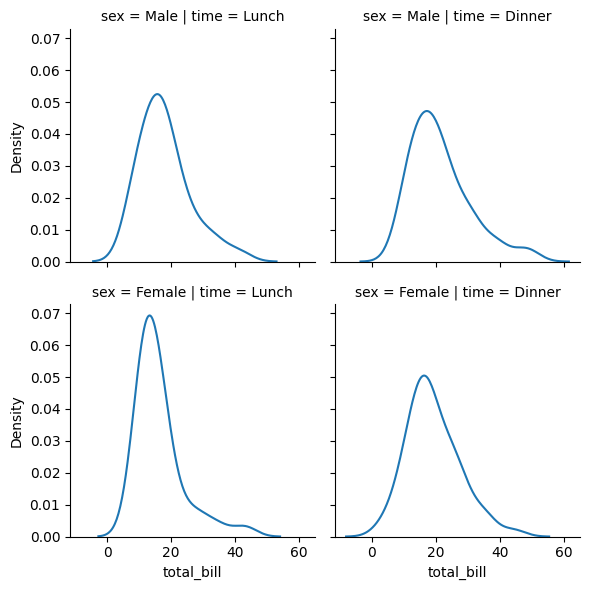

In [23]:
pl = sns.FacetGrid(data = data, row = 'sex', col = 'time')
pl.map(sns.kdeplot, 'total_bill')

**What insights can be derived from the spread and outliers of all numerical features in the tips dataset?**

In [24]:
# box plot
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

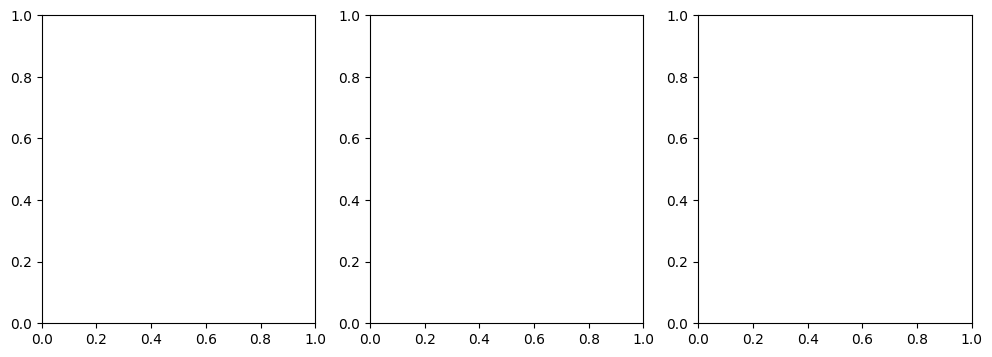

In [25]:
 plt.subplots(1, 3, figsize = (12, 4))

<Axes: ylabel='total_bill'>

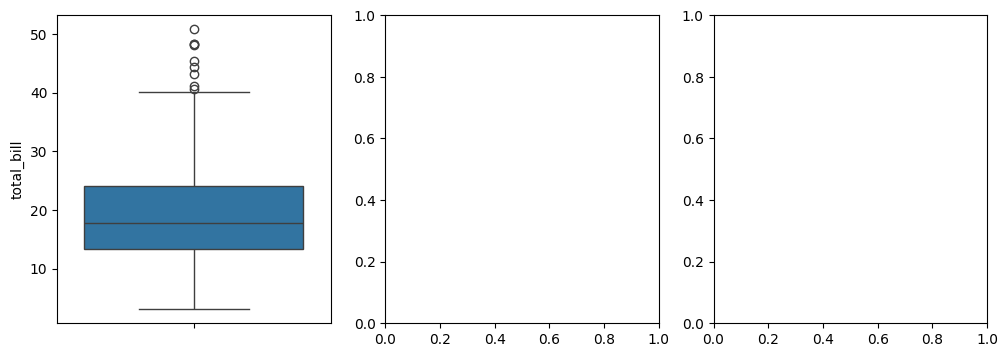

In [29]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
sns.boxplot(data = data, y = 'total_bill', ax = ax[0])

<Axes: ylabel='tip'>

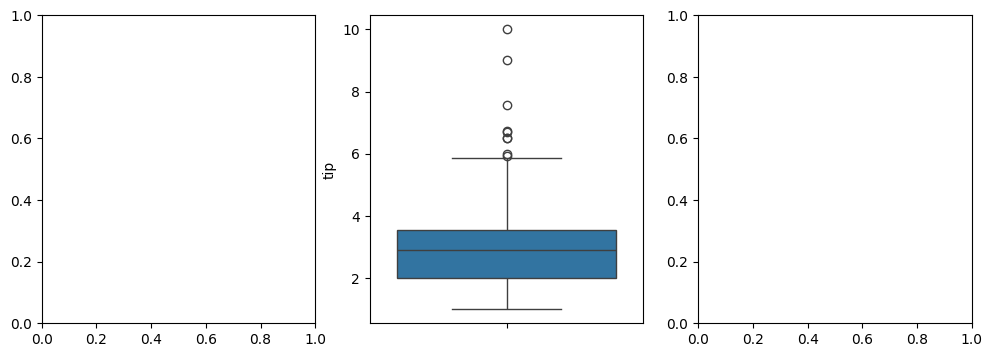

In [32]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
sns.boxplot(data = data, y = 'tip', ax = ax[1])

<Axes: ylabel='size'>

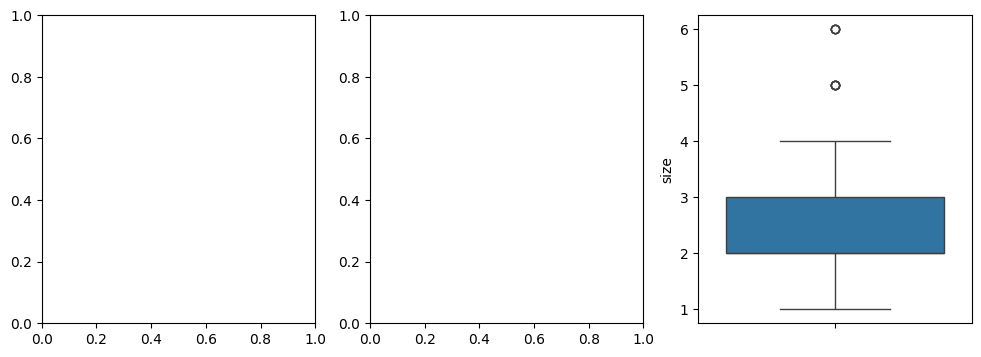

In [33]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
sns.boxplot(data = data, y = 'size', ax = ax[2])

Text(0.5, 1.0, 'Size')

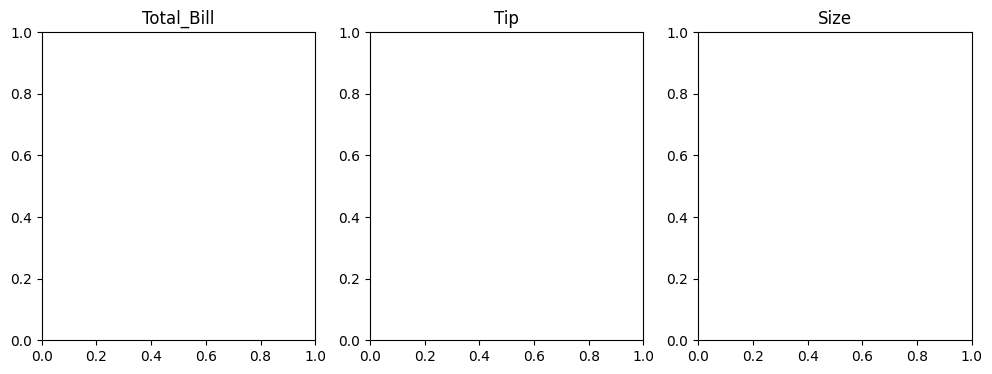

In [34]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
ax[0].set_title('Total_Bill')
ax[1].set_title('Tip')
ax[2].set_title('Size')

<Axes: title={'center': 'Size'}, ylabel='total_bill'>

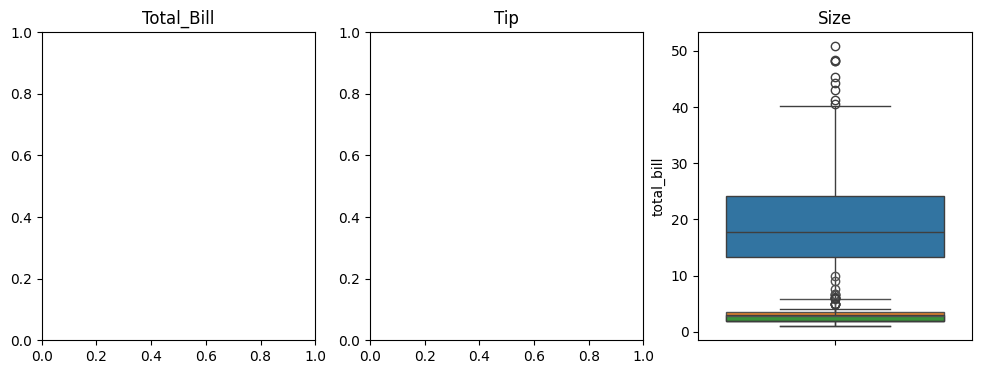

In [37]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
ax[0].set_title('Total_Bill')
sns.boxplot(data = data, y = 'total_bill')
ax[1].set_title('Tip')
sns.boxplot(data = data, y = 'tip')
ax[2].set_title('Size')
sns.boxplot(data = data, y = 'size')

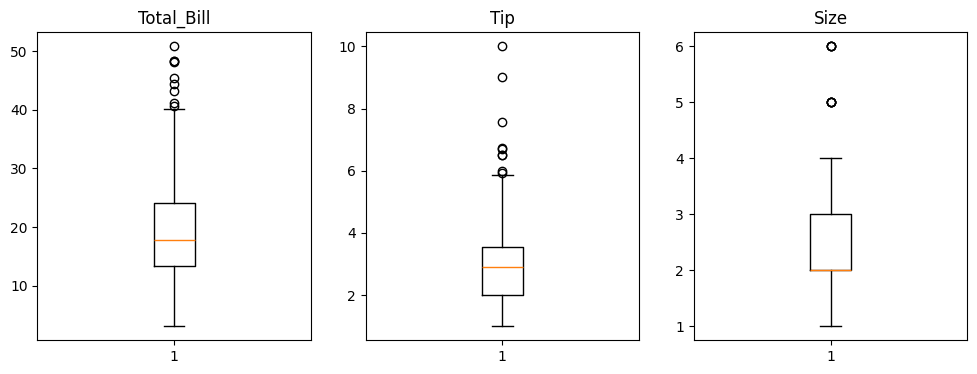

In [38]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
ax[0].set_title('Total_Bill')
ax[0].boxplot(data['total_bill'])
ax[1].set_title('Tip')
ax[1].boxplot(data['tip'])
ax[2].set_title('Size')
ax[2].boxplot(data['size'])
plt.show()

<Axes: title={'center': 'Size'}, ylabel='size'>

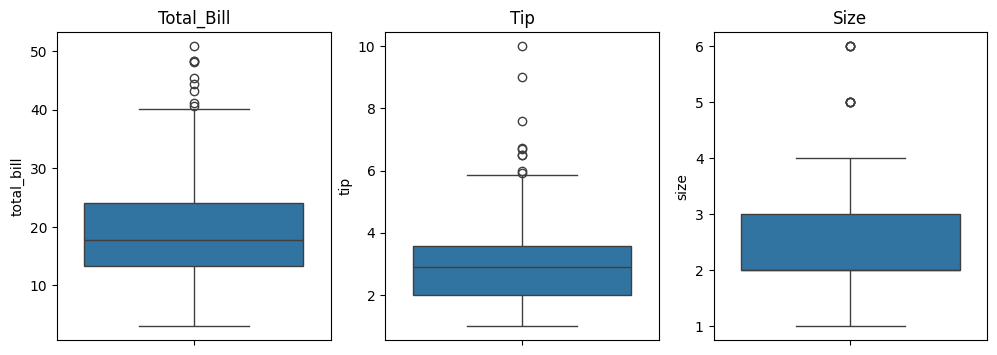

In [39]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
ax[0].set_title('Total_Bill')
sns.boxplot(data = data, y = 'total_bill', ax = ax[0])
ax[1].set_title('Tip')
sns.boxplot(data = data, y = 'tip', ax = ax[1])
ax[2].set_title('Size')
sns.boxplot(data = data, y = 'size', ax = ax[2])

**What is the relationship between total bill amounts and tips given by customers, and how does this relationship vary between male and female customers?**

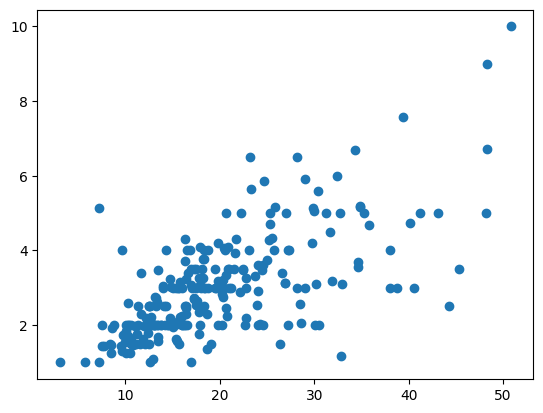

In [40]:
# matplotlib
plt.scatter(data['total_bill'], data['tip'])

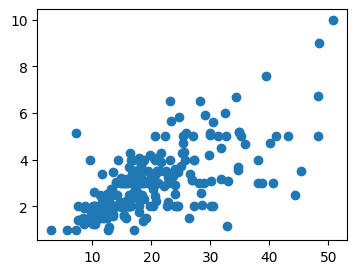

In [42]:
# matplotlib
plt.figure(figsize = (4, 3))
plt.scatter(data['total_bill'], data['tip'])

In [44]:
data[['total_bill', 'tip']]

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61
...,...,...
239,29.03,5.92
240,27.18,2.00
241,22.67,2.00
242,17.82,1.75


In [45]:
# Pearsons Correlation Coeffiecient - IF THE REL B/W VAR IS LINEAR
data[['total_bill', 'tip']].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


If the relationship between total bill and tip is not linear
- Use Spearmanns Correlation coeff

In [46]:
# Spearman correlation coefficient - IF THE REL B/W VAR IS NONLINEAR
data[['total_bill', 'tip']].corr('spearman')

,total_bill,tip
total_bill,1.000000,0.678968
tip,0.678968,1.000000


<Axes: xlabel='total_bill', ylabel='tip'>

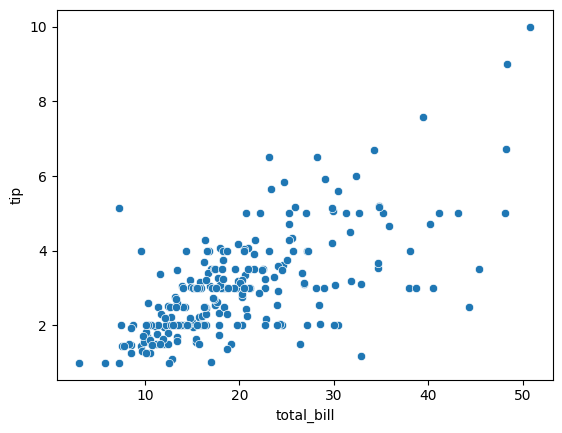

In [47]:
sns.scatterplot(data = data, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

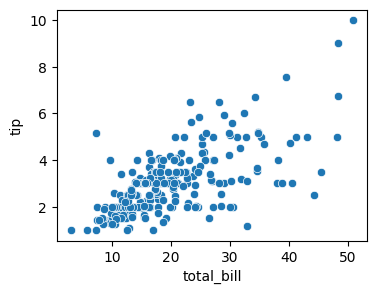

In [48]:
plt.figure(figsize = (4, 3))
sns.scatterplot(data = data, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

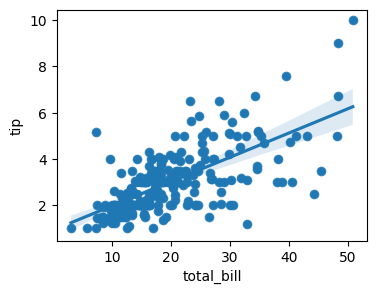

In [49]:
plt.figure(figsize = (4, 3))
sns.scatterplot(data = data, x = 'total_bill', y = 'tip')
sns.regplot(data = data, x = 'total_bill', y = 'tip')

In [50]:
help(plt.scatter)

Help on function scatter in module matplotlib.pyplot:

scatter(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    s: 'float | ArrayLike | None' = None,
    c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None,
    *,
    marker: 'MarkerType | None' = None,
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    alpha: 'float | None' = None,
    linewidths: 'float | Sequence[float] | None' = None,
    edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None,
    colorizer: 'Colorizer | None' = None,
    plotnonfinite: 'bool' = False,
    data=None,
    **kwargs
) -> 'PathCollection'
    A scatter plot of *y* vs. *x* with varying marker size and/or color.

    Parameters
    ----------
    x, y : float or array-like, shape (n, )
        The data positions.

    s : float or array-like, shape (n, ), optional
        The marker size in points**

<Axes: xlabel='total_bill', ylabel='tip'>

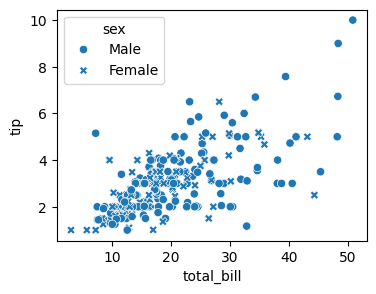

In [51]:
plt.figure(figsize = (4, 3))
sns.scatterplot(data = data, x = 'total_bill', y = 'tip', style = 'sex')

In [ ]:

plt.scatter(x = data['total_bill'],
            )

**What is the realtionship between total bill amounts and tips given by customers, and how does this relationship differ based on smoking status and gender?**

<Axes: xlabel='total_bill', ylabel='tip'>

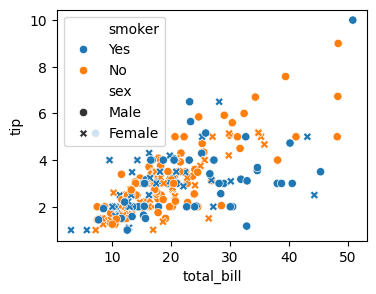

In [52]:
plt.figure(figsize = (4, 3))
sns.scatterplot(data = data, x = 'total_bill', y = 'tip', hue = 'smoker', style = 'sex')

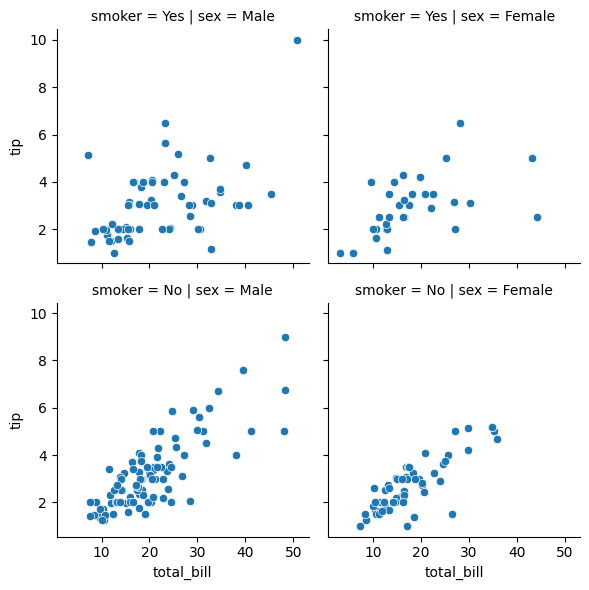

In [55]:
g = sns.FacetGrid(data = data, row = 'smoker', col = 'sex')
g.map(sns.scatterplot, 'total_bill', 'tip')